
[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



Processing: ZDT1 (SGMGPSO-FULL)
  Trial 30/30 running...
  [Done] ZDT1 — 30 trials completed.
  IGD: 0.003936 ± 0.000307
  HV:  5.902020 ± 0.002709


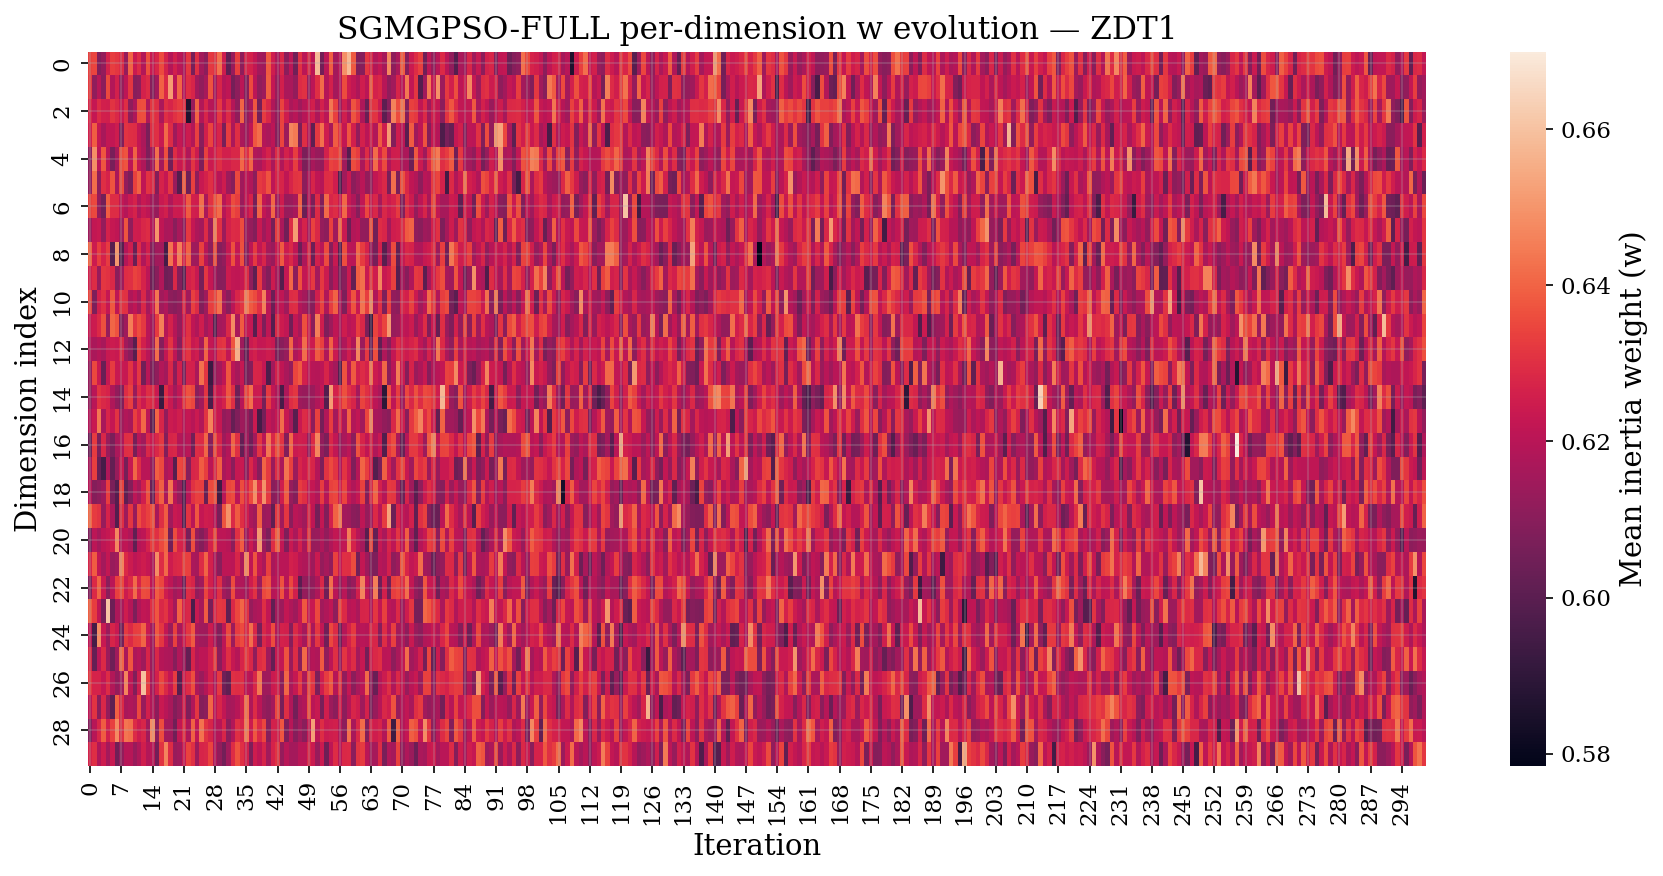

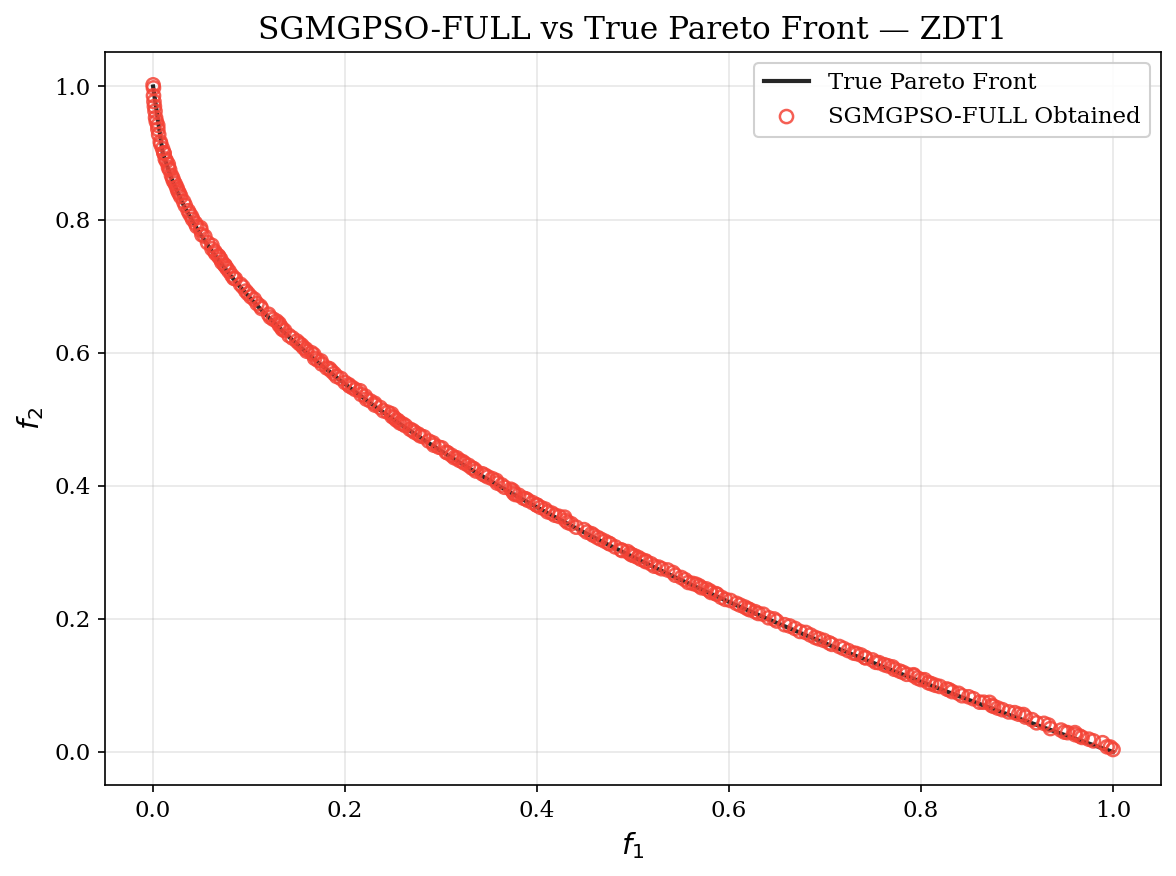


Processing: ZDT2 (SGMGPSO-FULL)
  Trial 30/30 running...
  [Done] ZDT2 — 30 trials completed.
  IGD: 0.026514 ± 0.016496
  HV:  5.193729 ± 0.203554


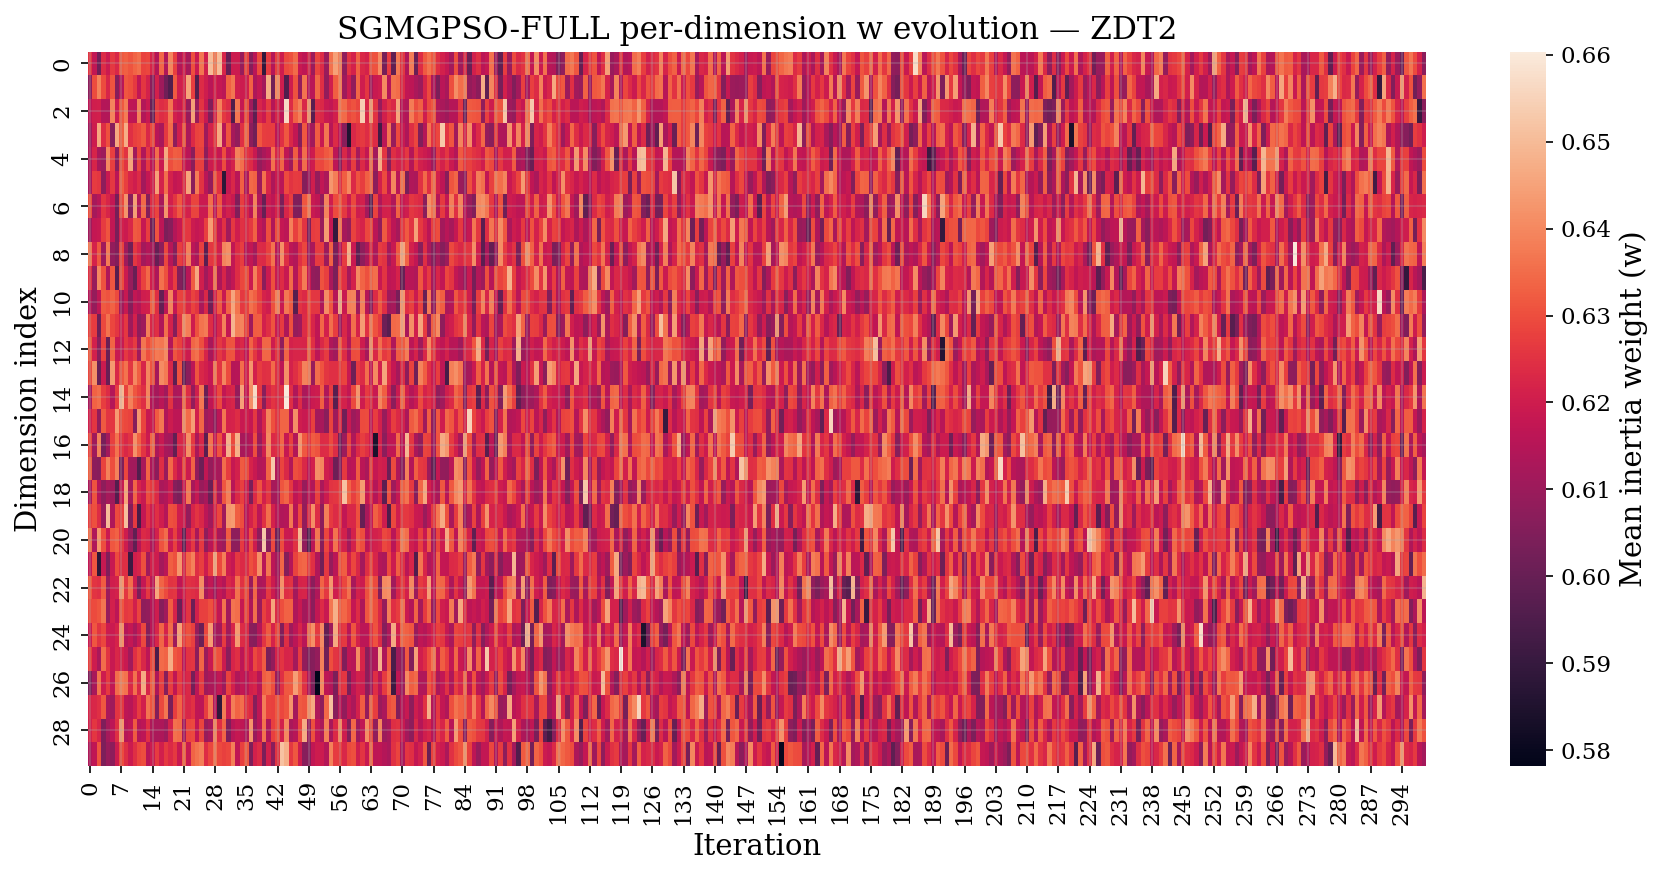

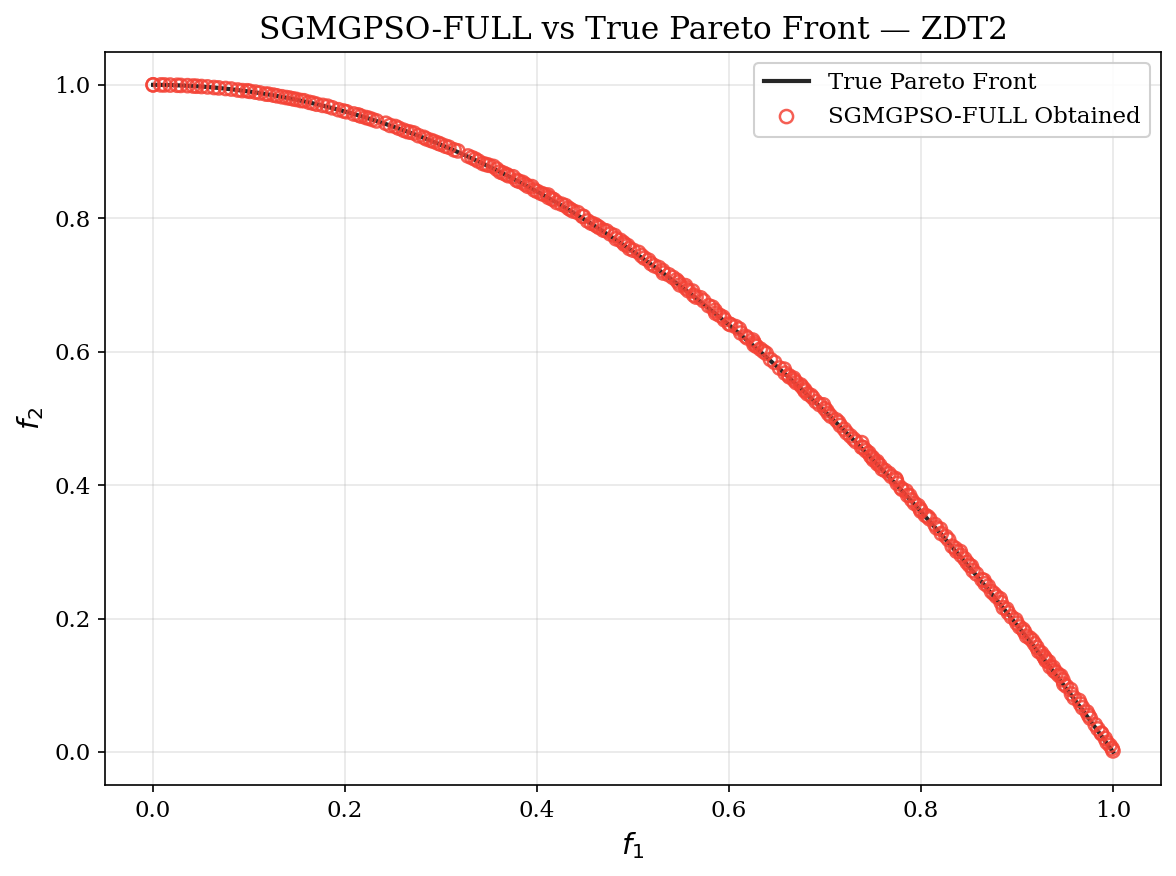


Processing: ZDT3 (SGMGPSO-FULL)
  Trial 30/30 running...
  [Done] ZDT3 — 30 trials completed.
  IGD: 0.010351 ± 0.002024
  HV:  7.389936 ± 0.011597


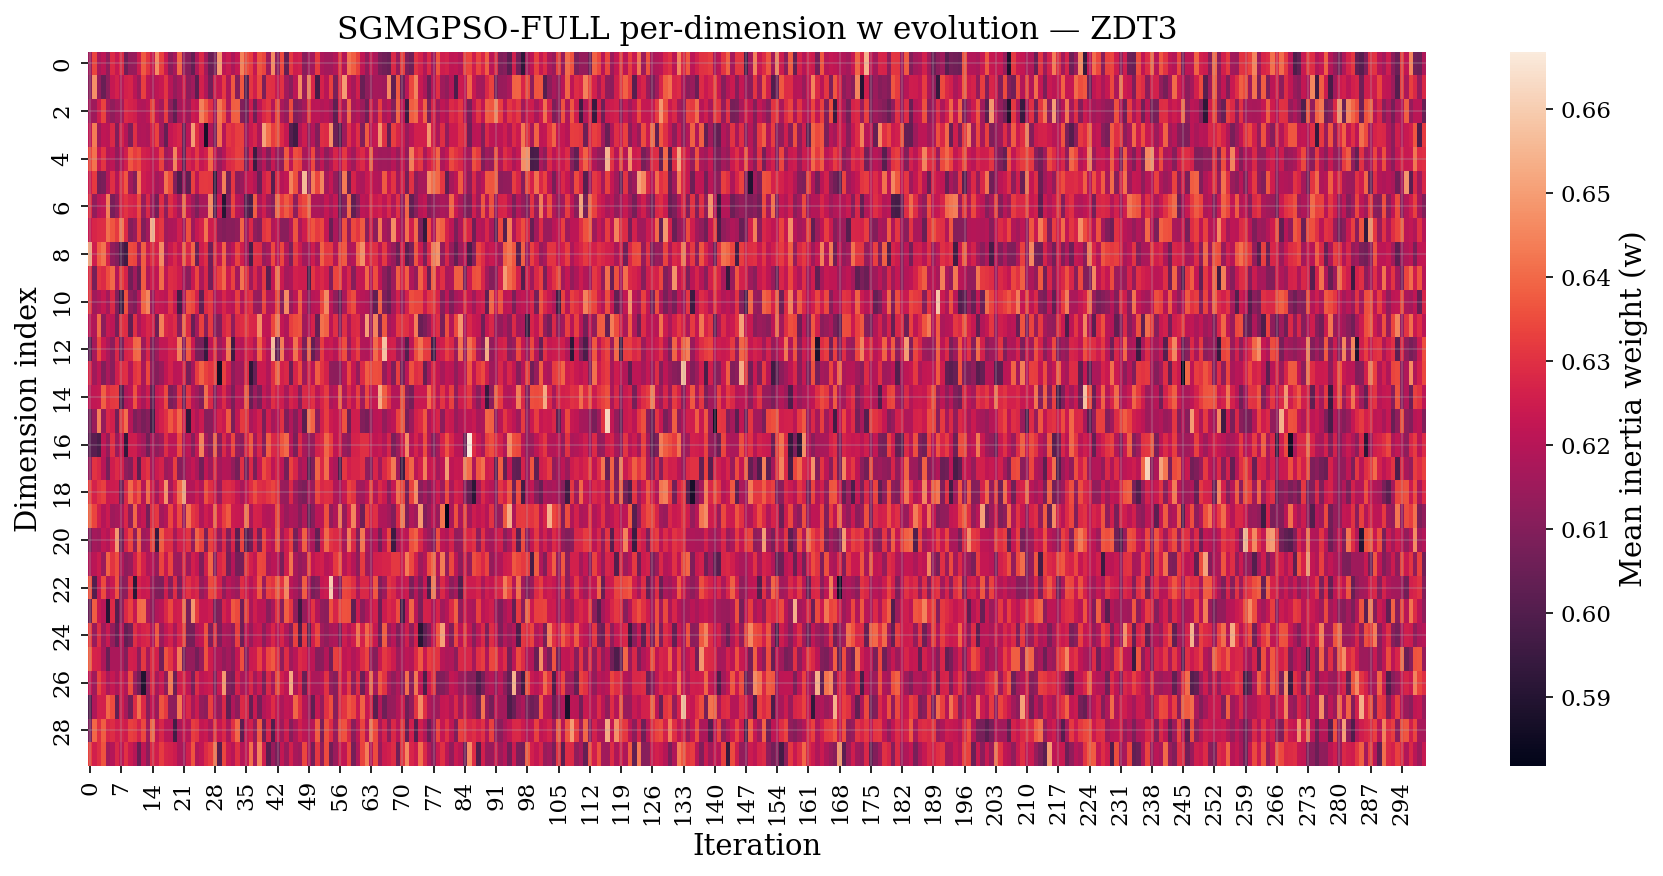

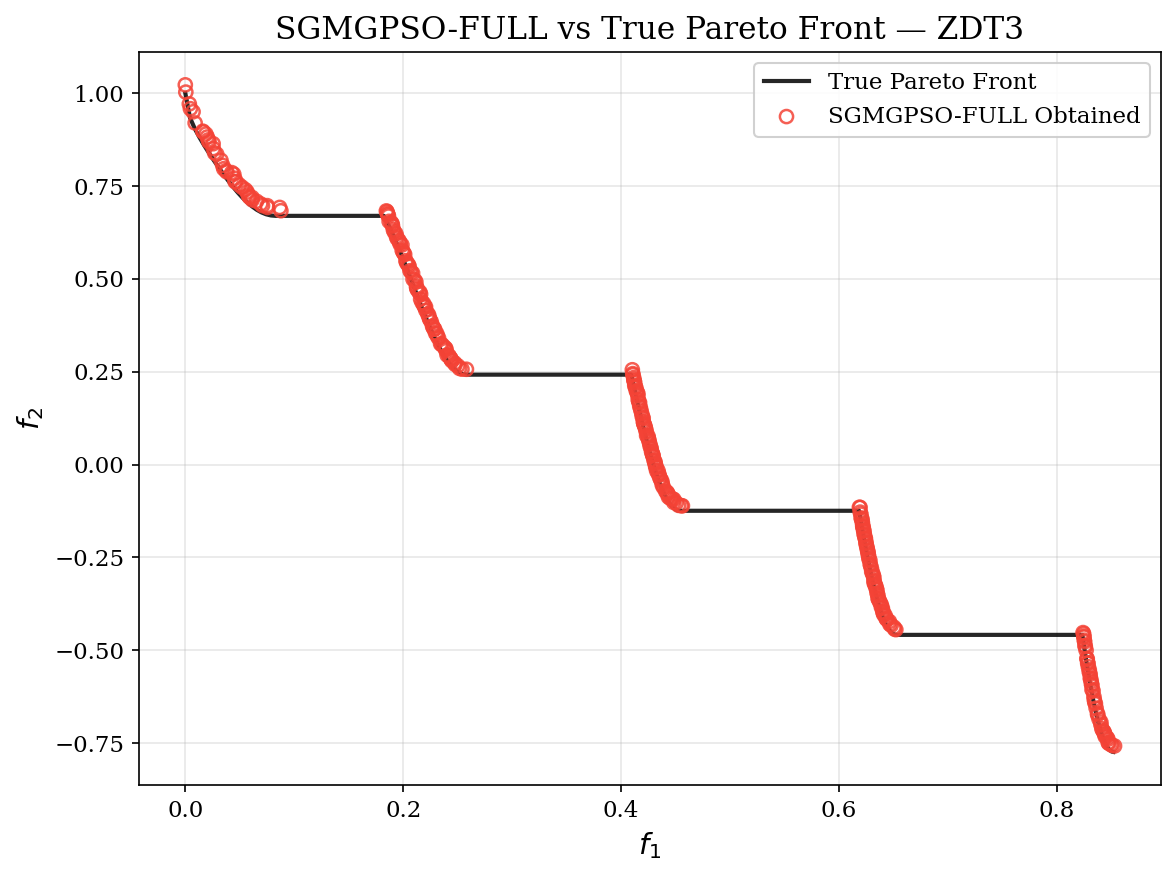


Processing: ZDT4 (SGMGPSO-FULL)
  Trial 30/30 running...
  [Done] ZDT4 — 30 trials completed.
  IGD: 16.701162 ± 3.475883
  HV:  0.000000 ± 0.000000


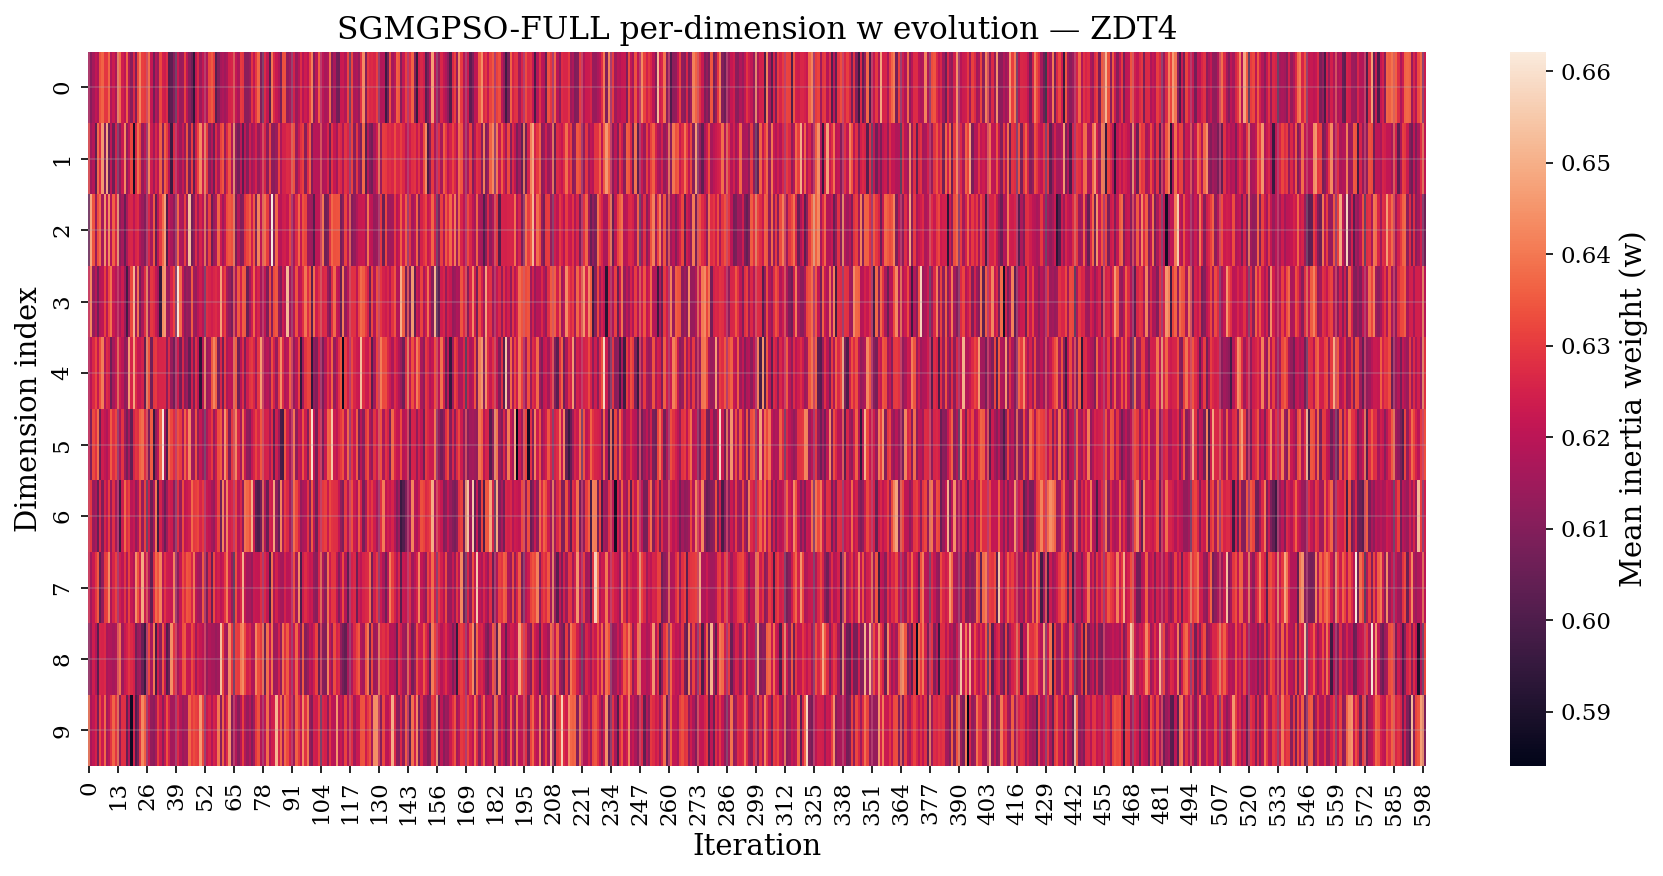

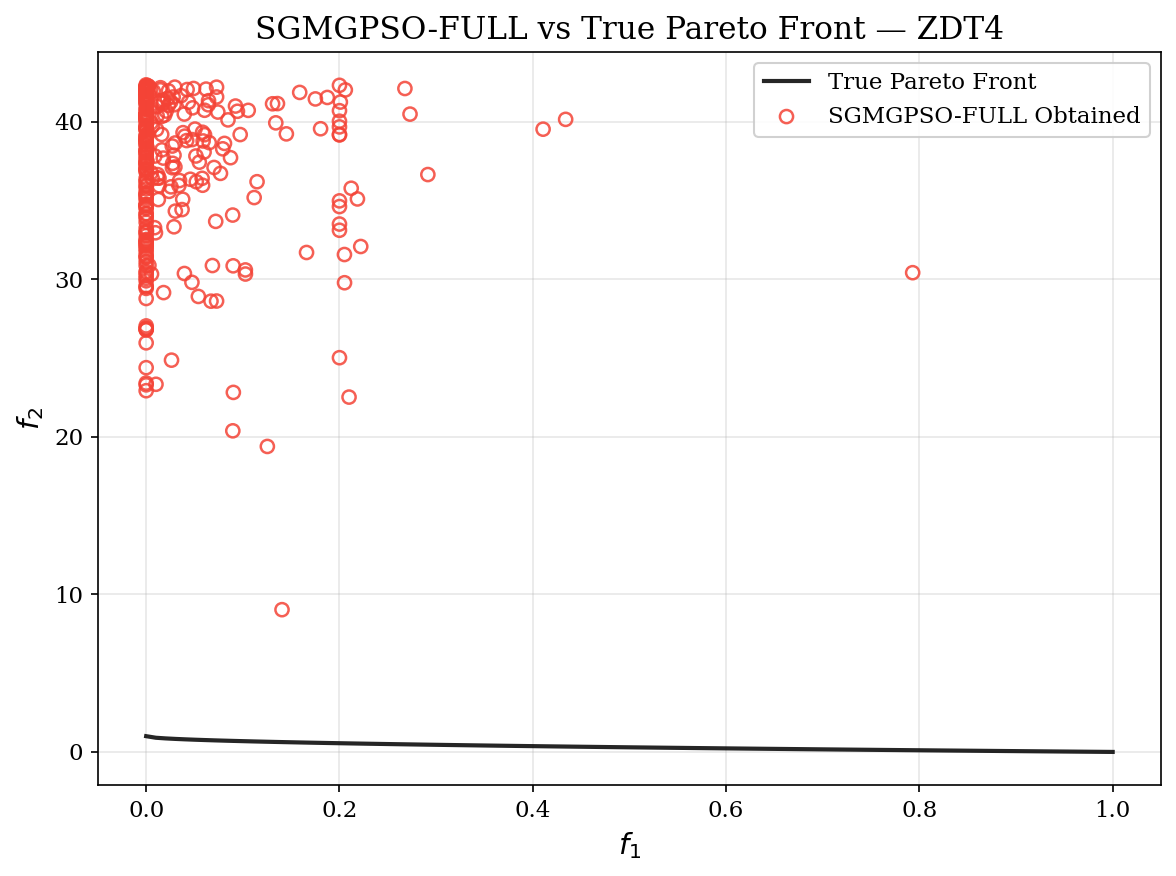


Processing: ZDT6 (SGMGPSO-FULL)
  Trial 30/30 running...
  [Done] ZDT6 — 30 trials completed.
  IGD: 0.001142 ± 0.000086
  HV:  5.153511 ± 0.000020


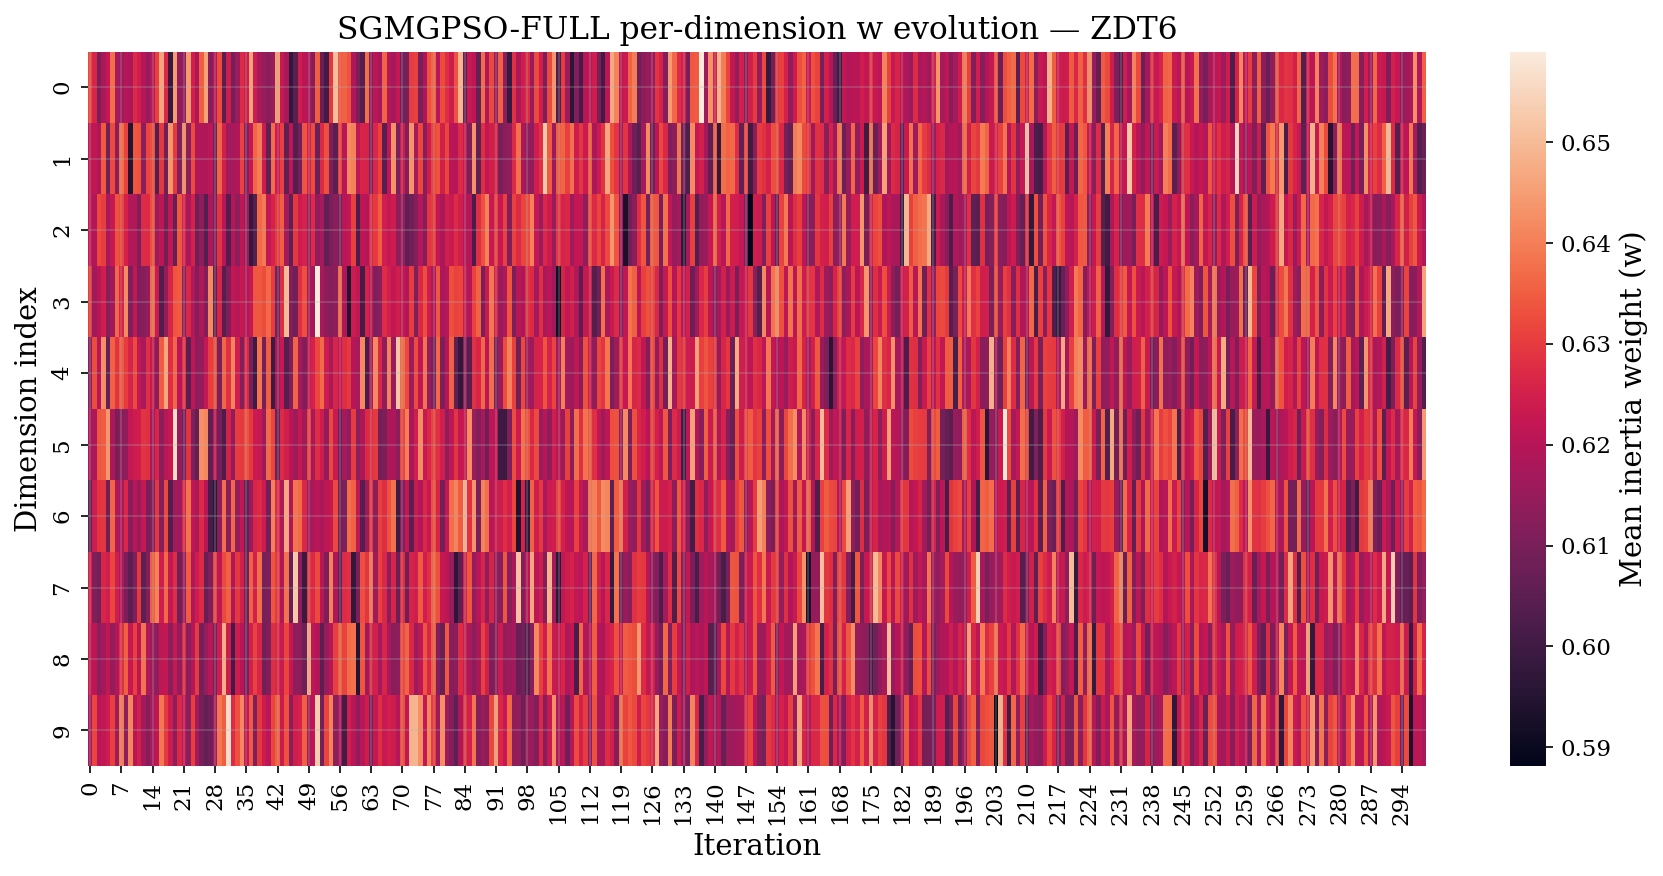

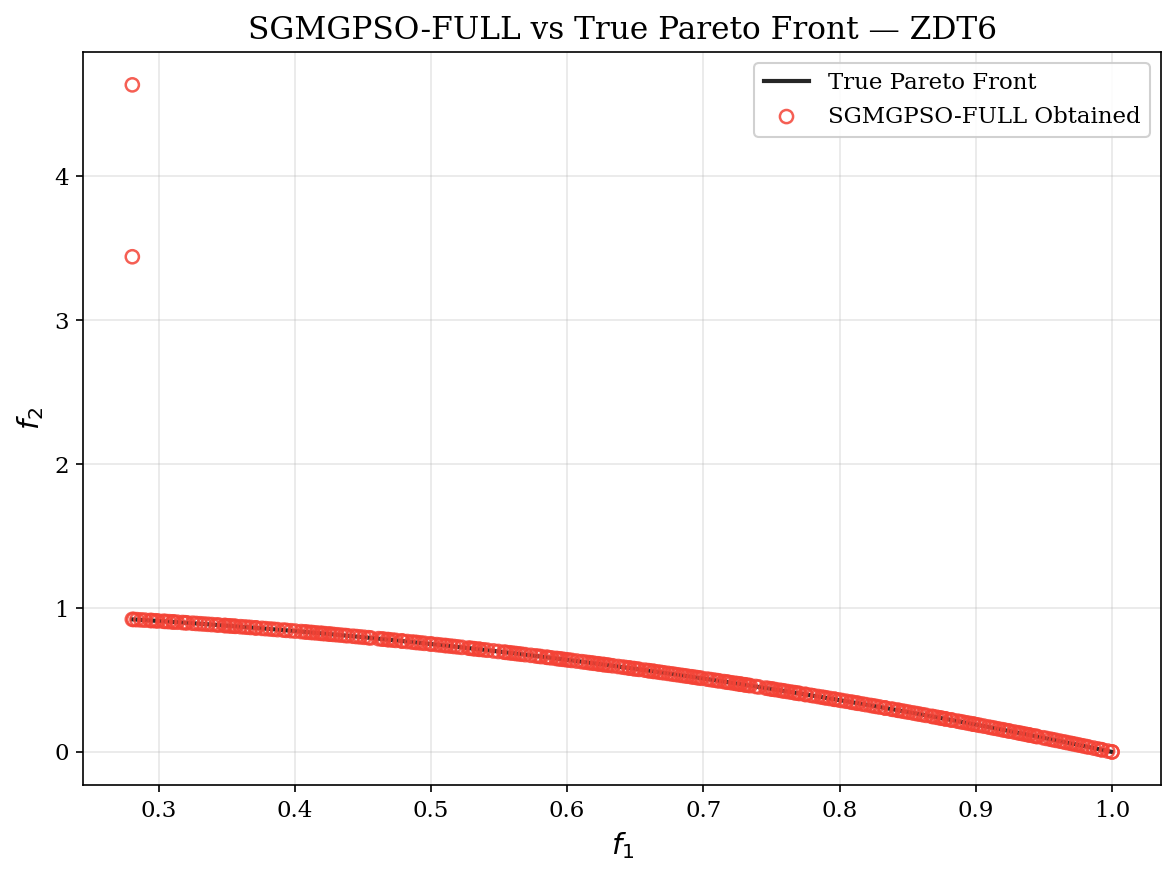


Processing: WFG1 (SGMGPSO-FULL)
  Trial 30/30 running...
  [Done] WFG1 — 30 trials completed.
  IGD: 1.428454 ± 0.019600
  HV:  45.035514 ± 0.548683


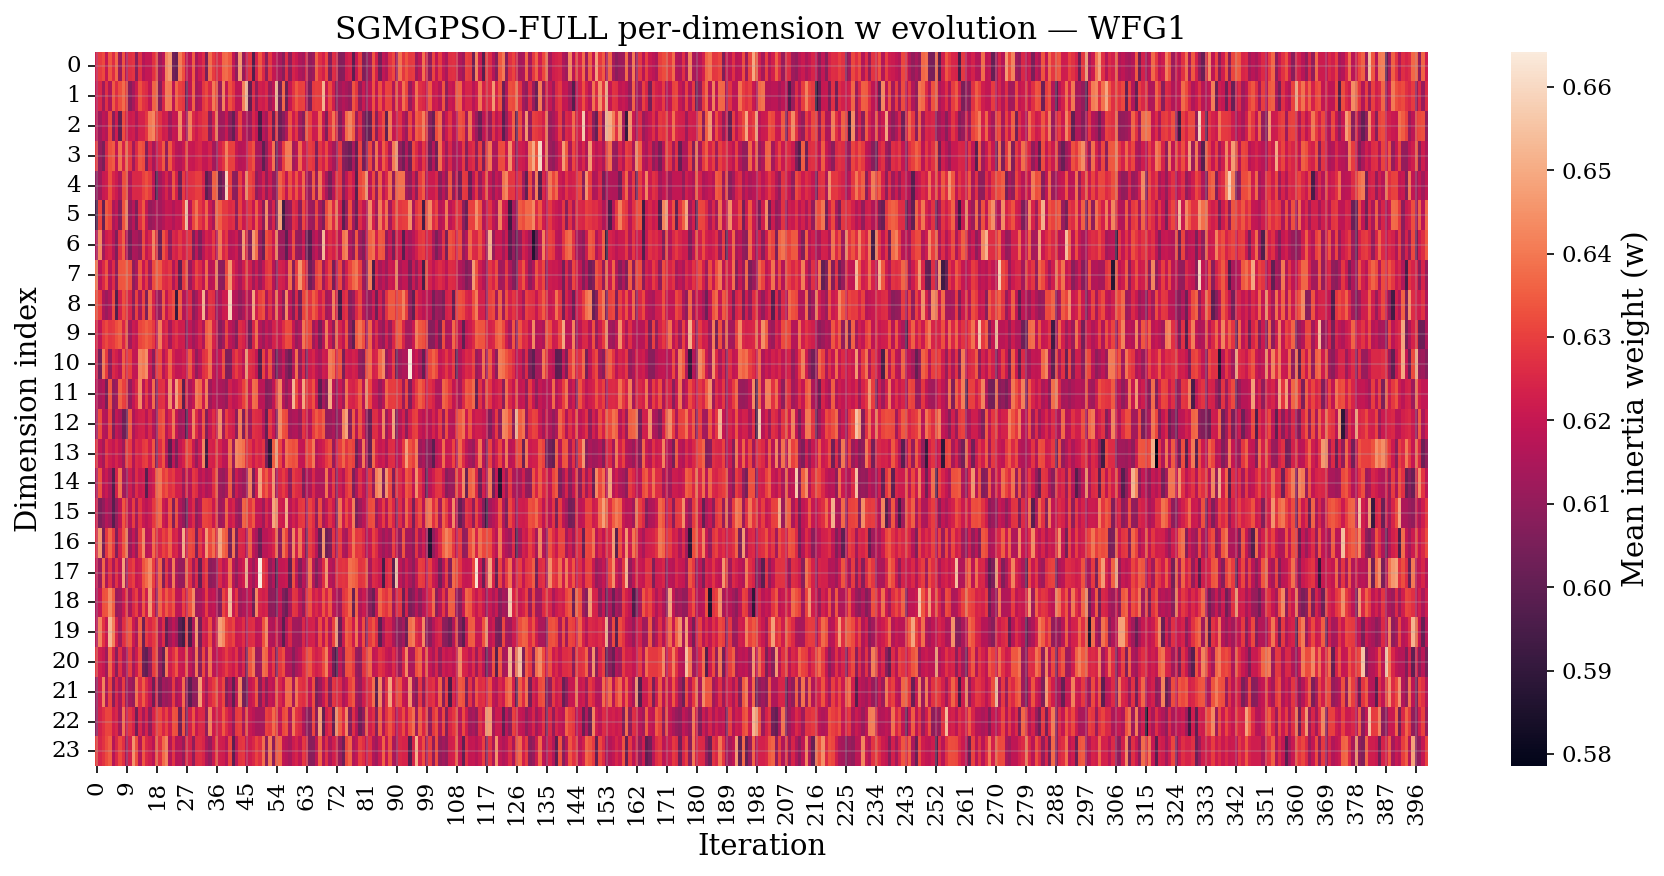

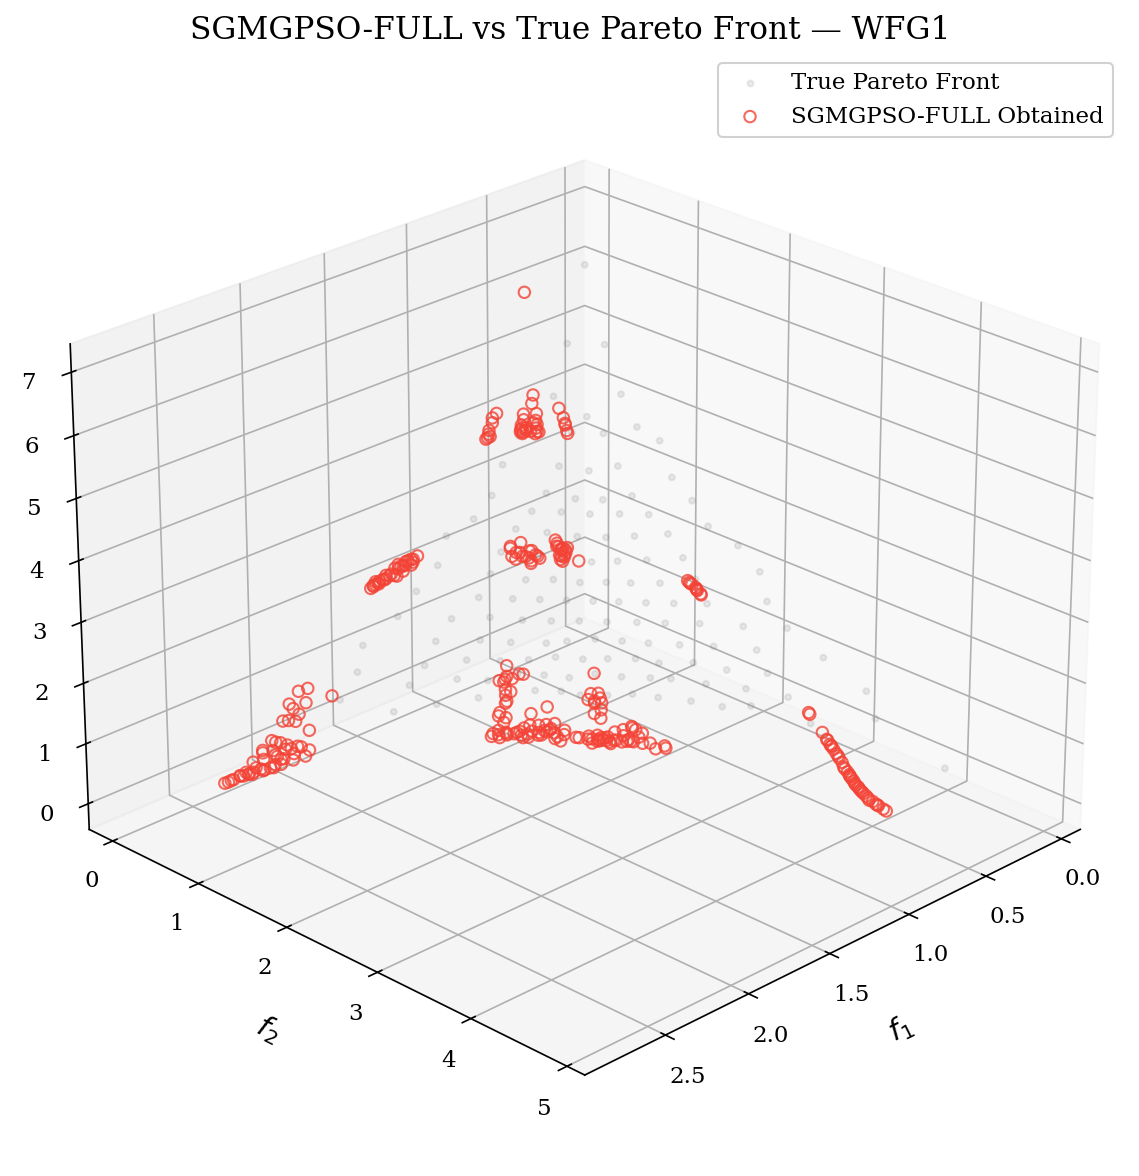


Processing: WFG2 (SGMGPSO-FULL)
  Trial 30/30 running...
  [Done] WFG2 — 30 trials completed.
  IGD: 0.322454 ± 0.101614
  HV:  90.582110 ± 4.662461


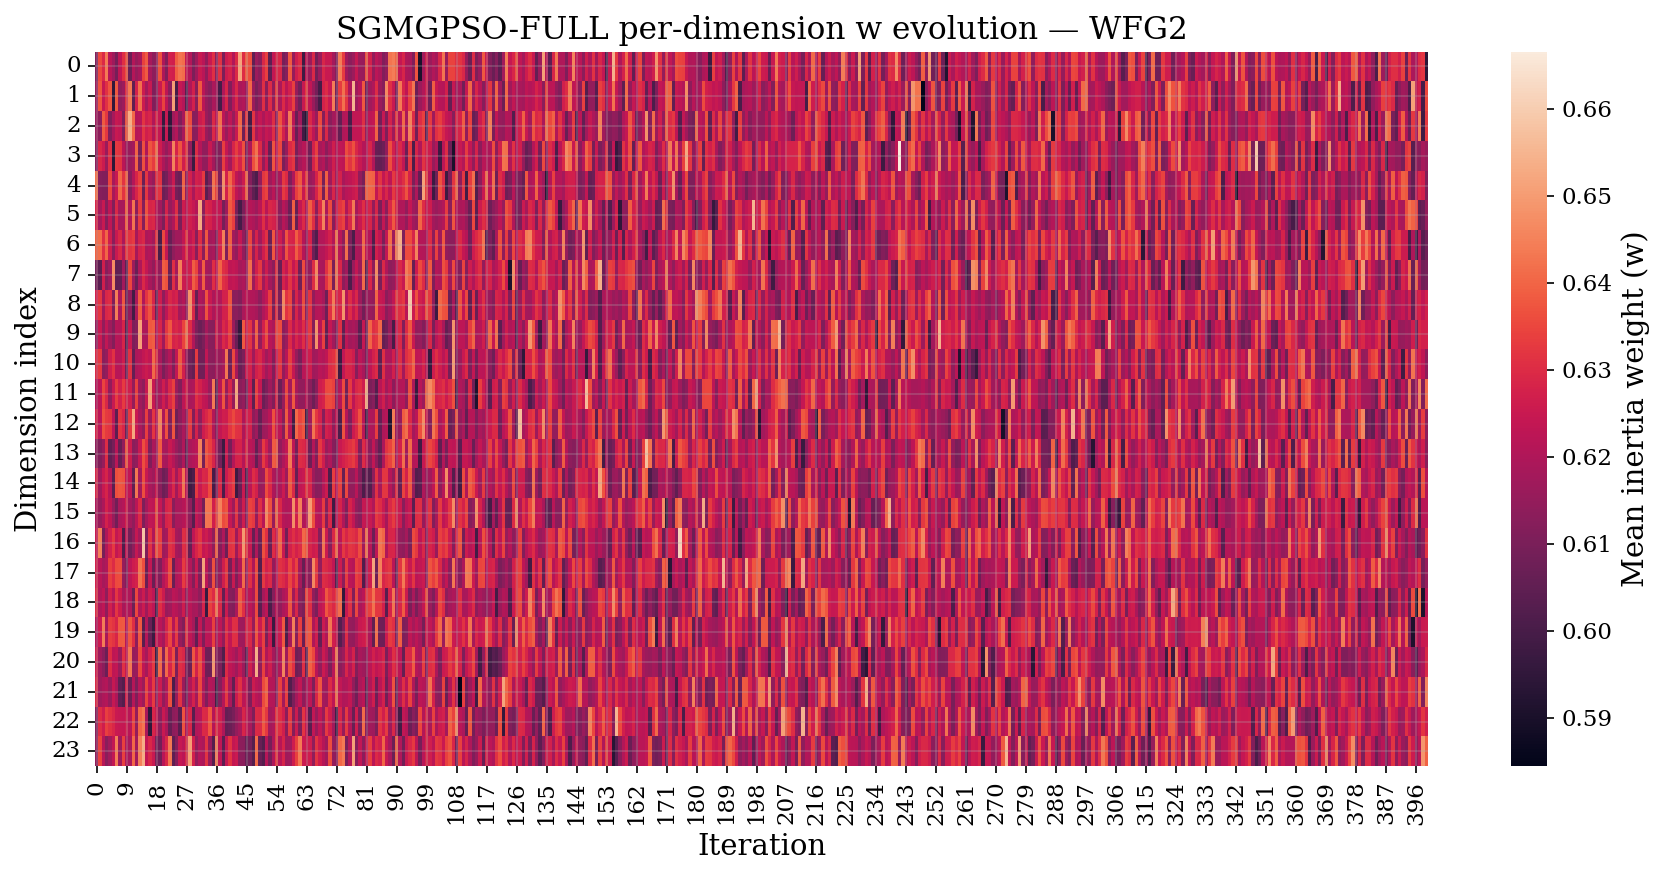

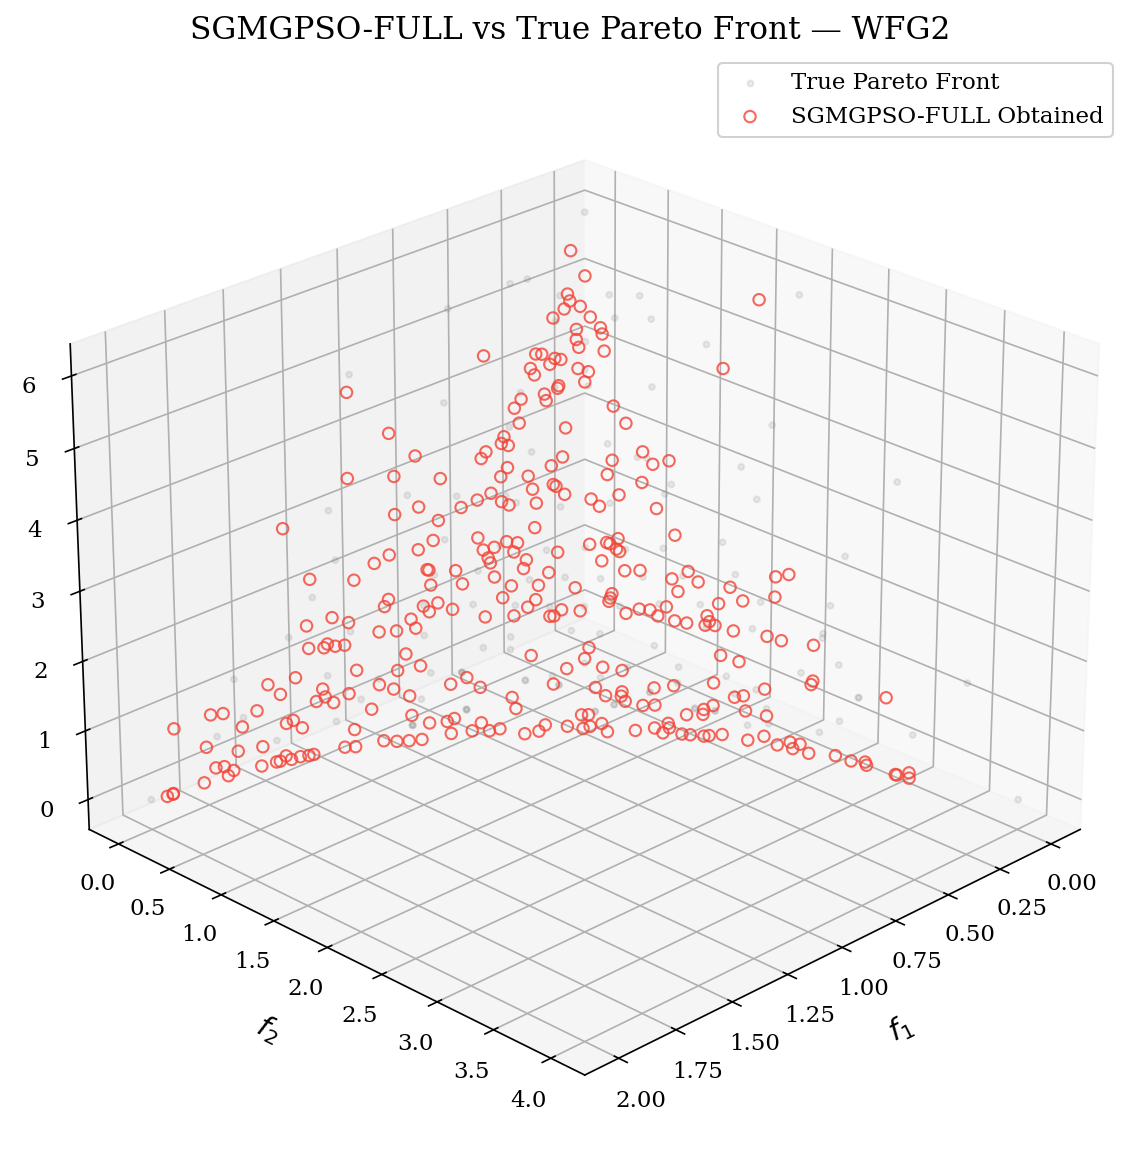


Processing: WFG3 (SGMGPSO-FULL)
  Trial 30/30 running...
  [Done] WFG3 — 30 trials completed.
  IGD: 0.248896 ± 0.028054
  HV:  66.420844 ± 1.093959


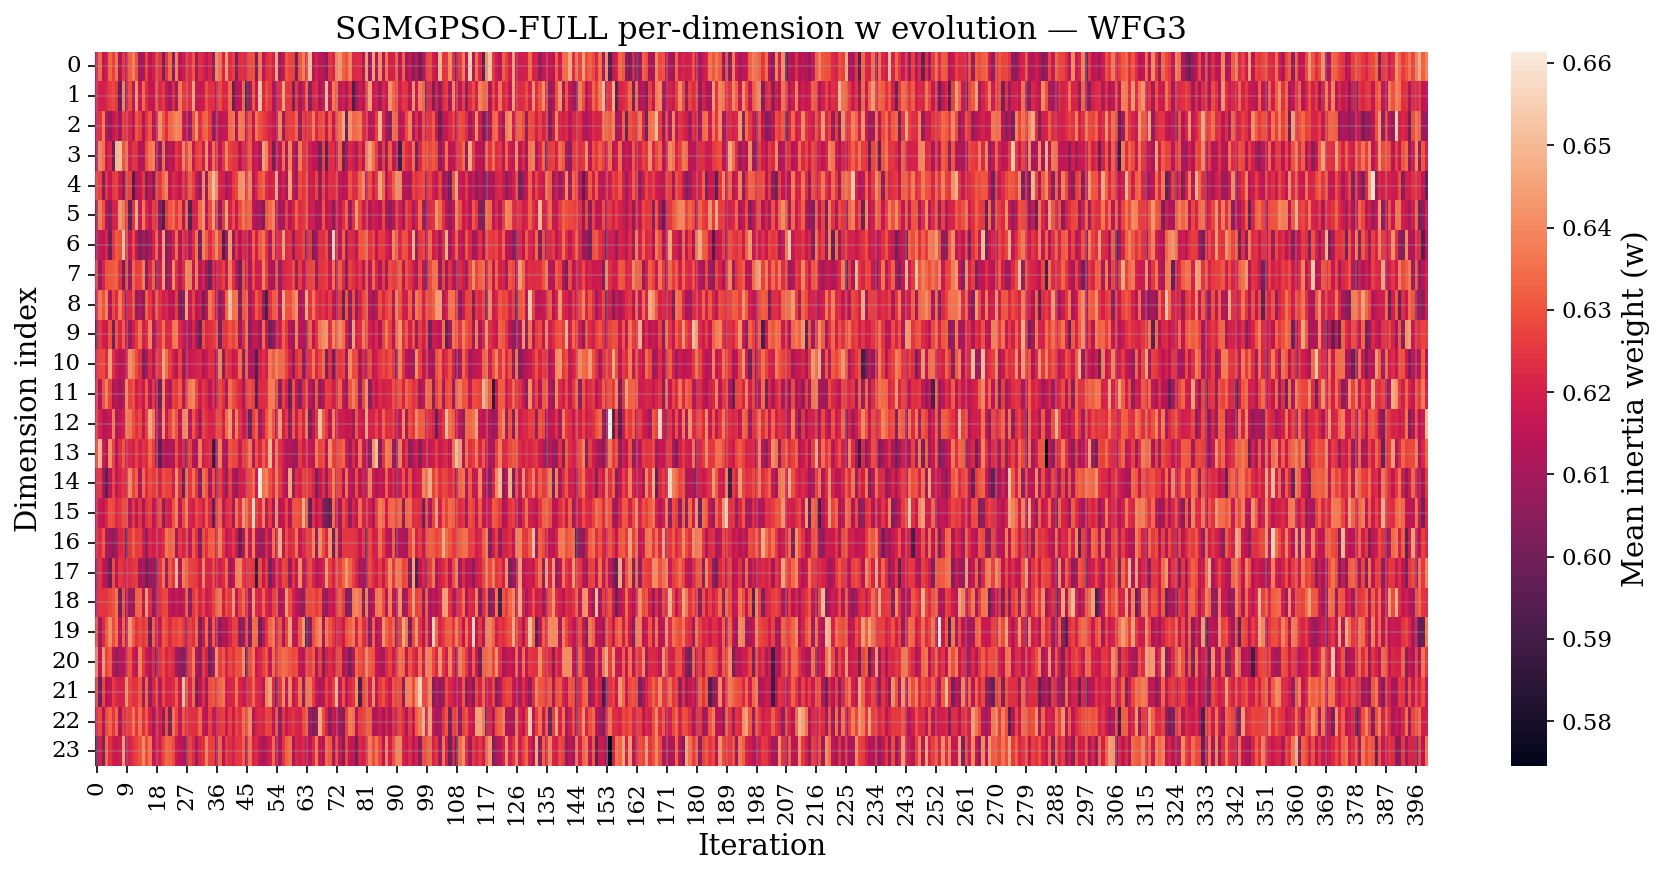

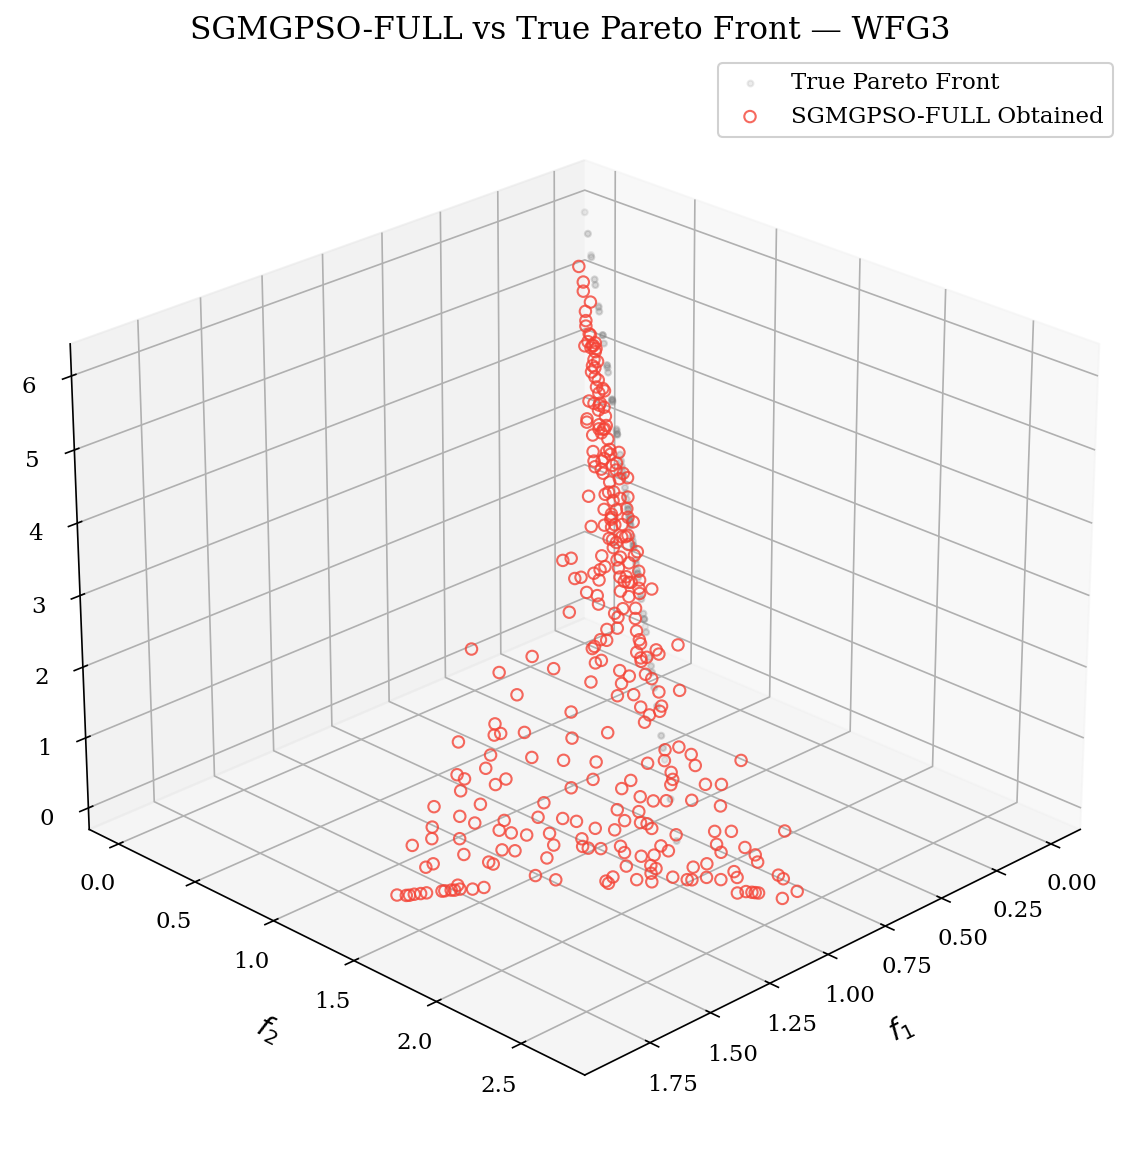


Processing: WFG4 (SGMGPSO-FULL)
  Trial 30/30 running...
  [Done] WFG4 — 30 trials completed.
  IGD: 0.230761 ± 0.007138
  HV:  69.789158 ± 0.303843


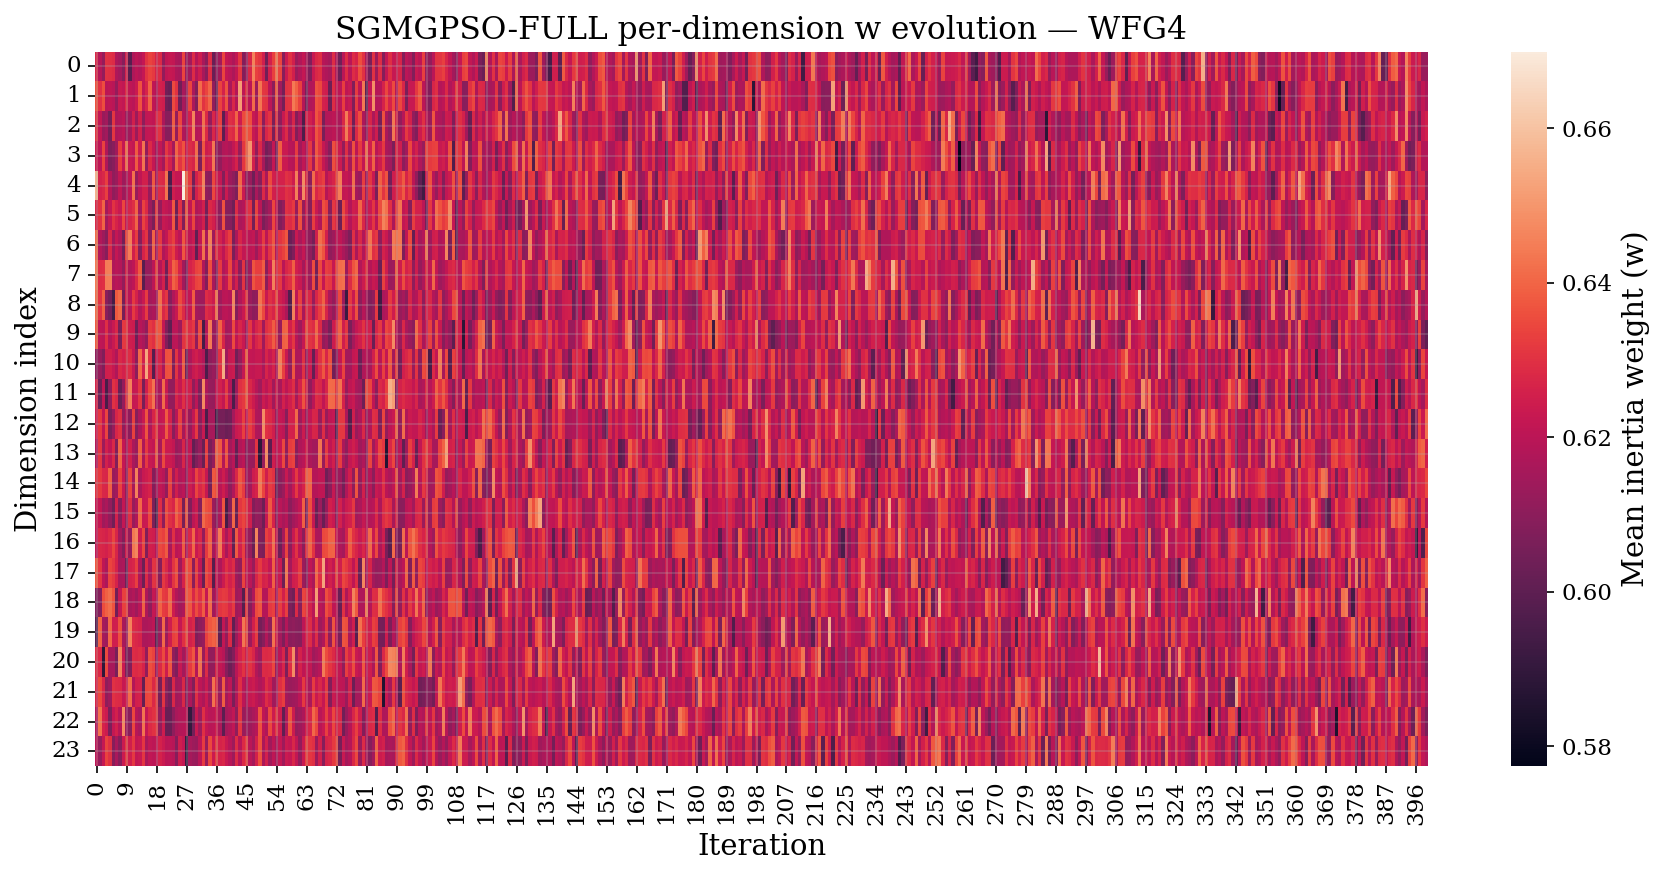

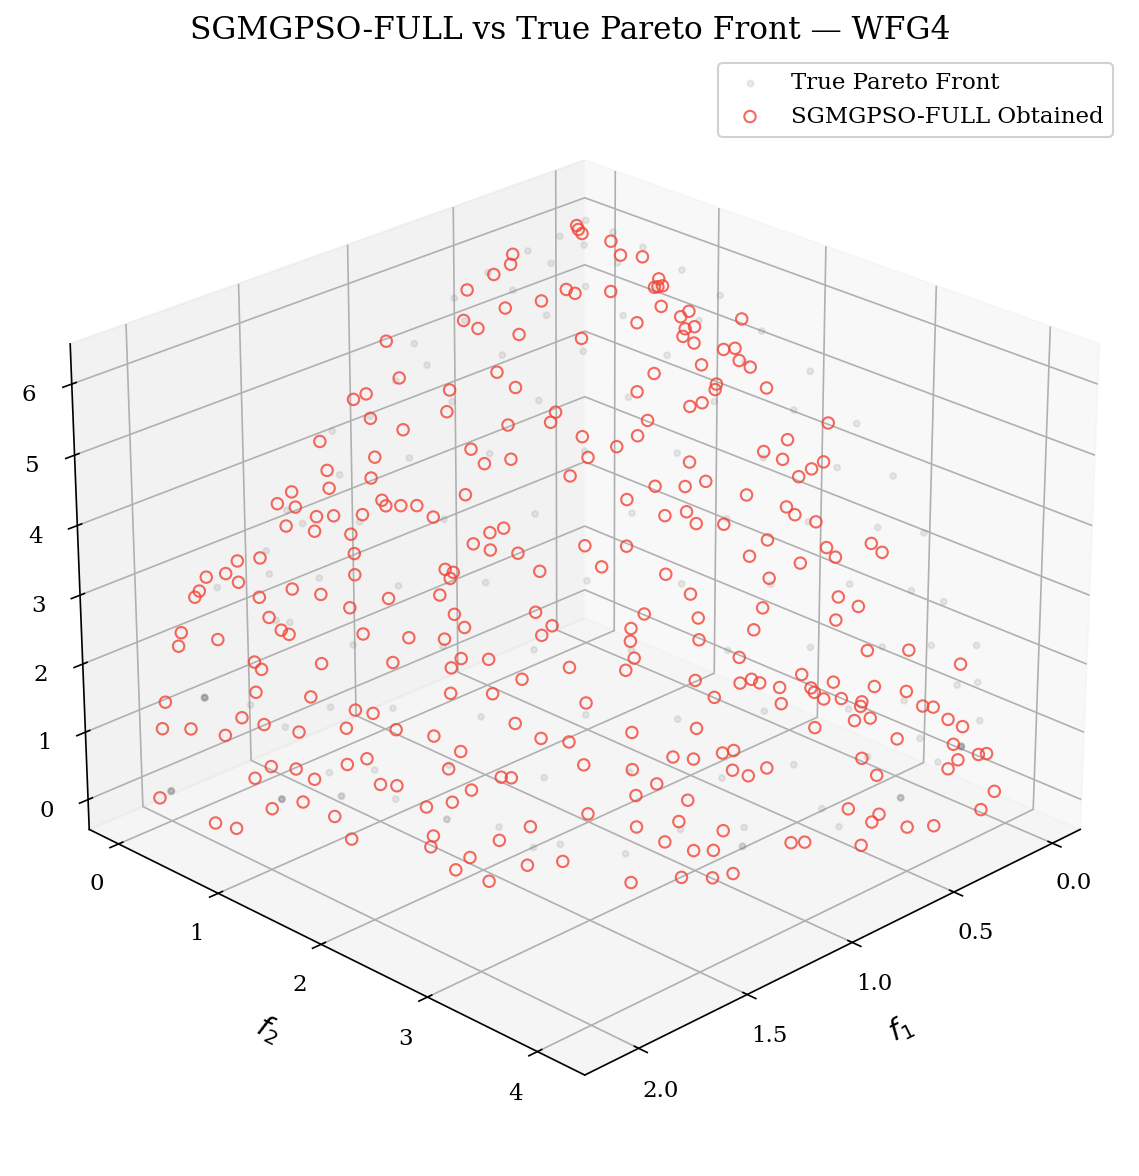


Processing: WFG5 (SGMGPSO-FULL)
  Trial 30/30 running...
  [Done] WFG5 — 30 trials completed.
  IGD: 0.472887 ± 0.114580
  HV:  56.068602 ± 4.882350


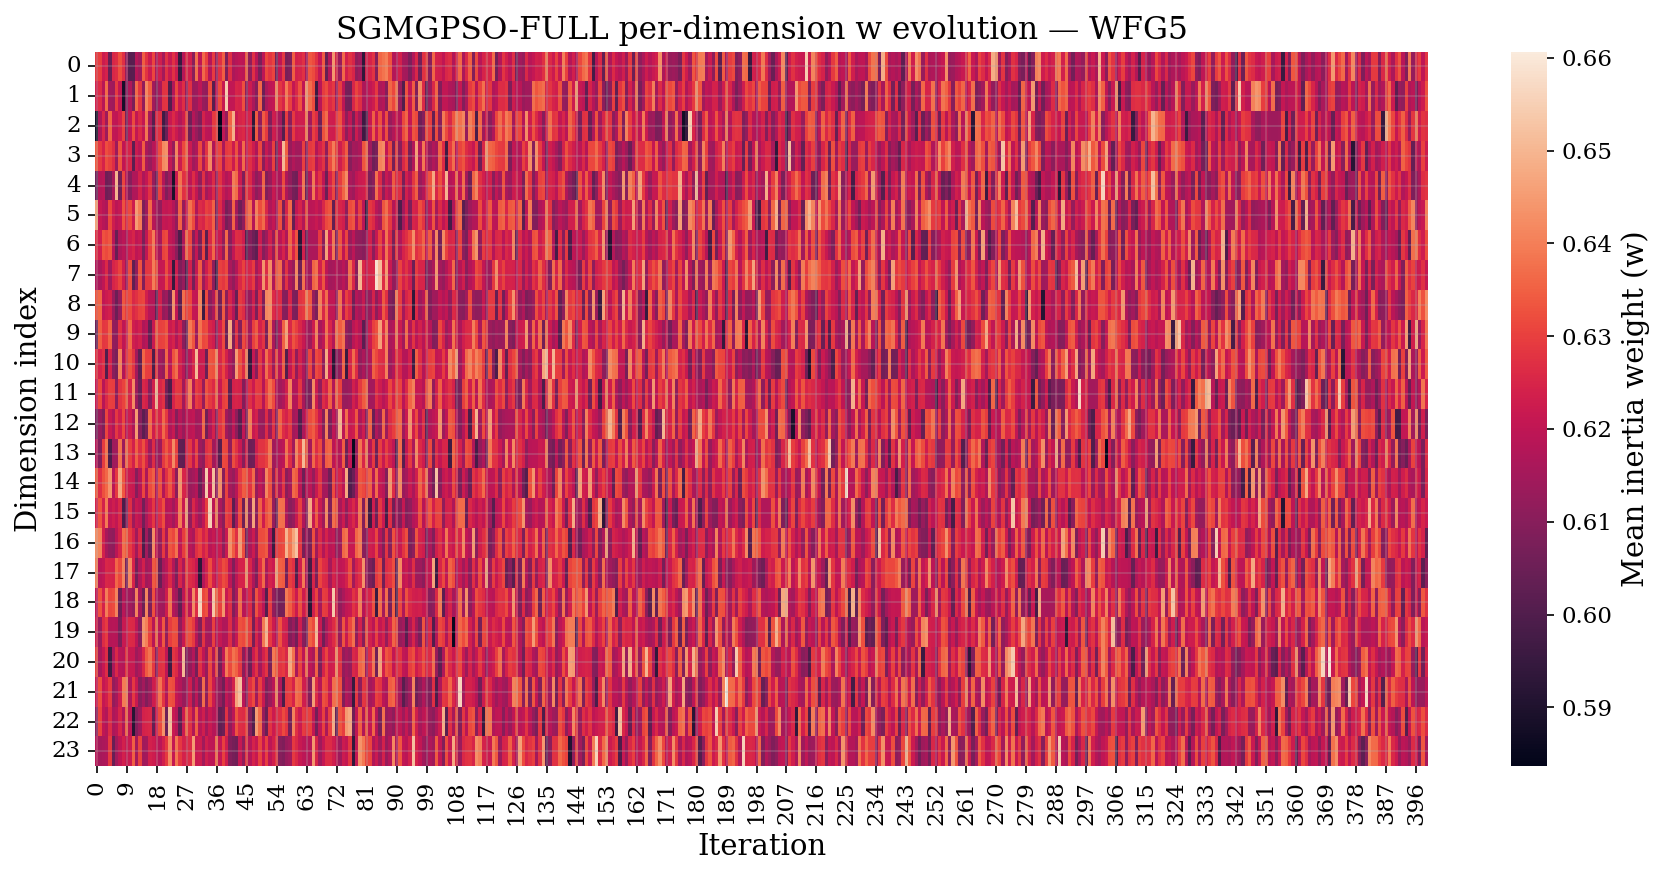

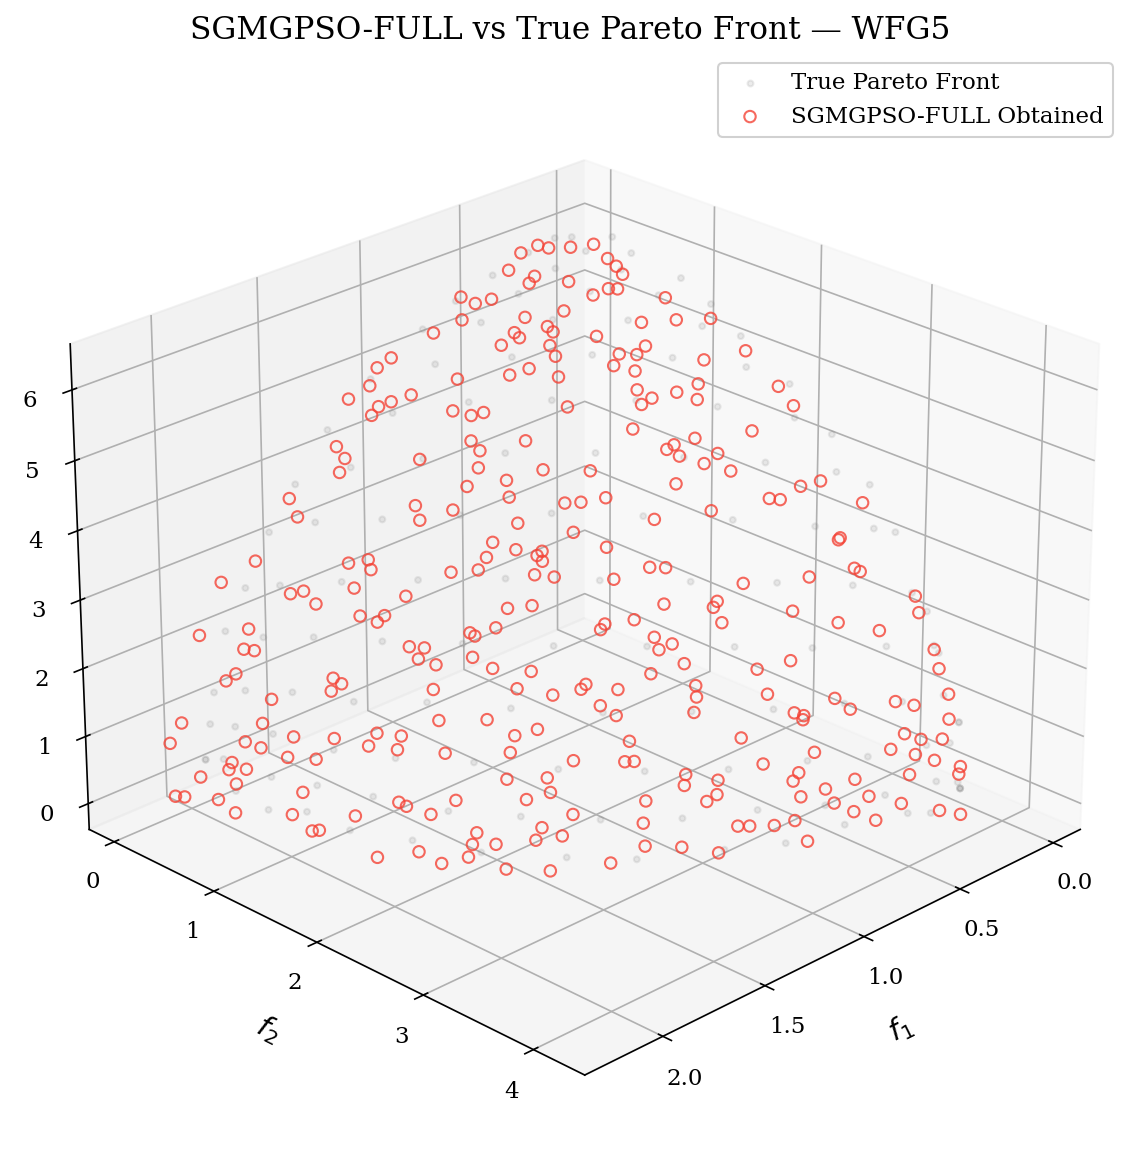


Processing: WFG6 (SGMGPSO-FULL)
  Trial 30/30 running...
  [Done] WFG6 — 30 trials completed.
  IGD: 0.317614 ± 0.014837
  HV:  66.122876 ± 0.663496


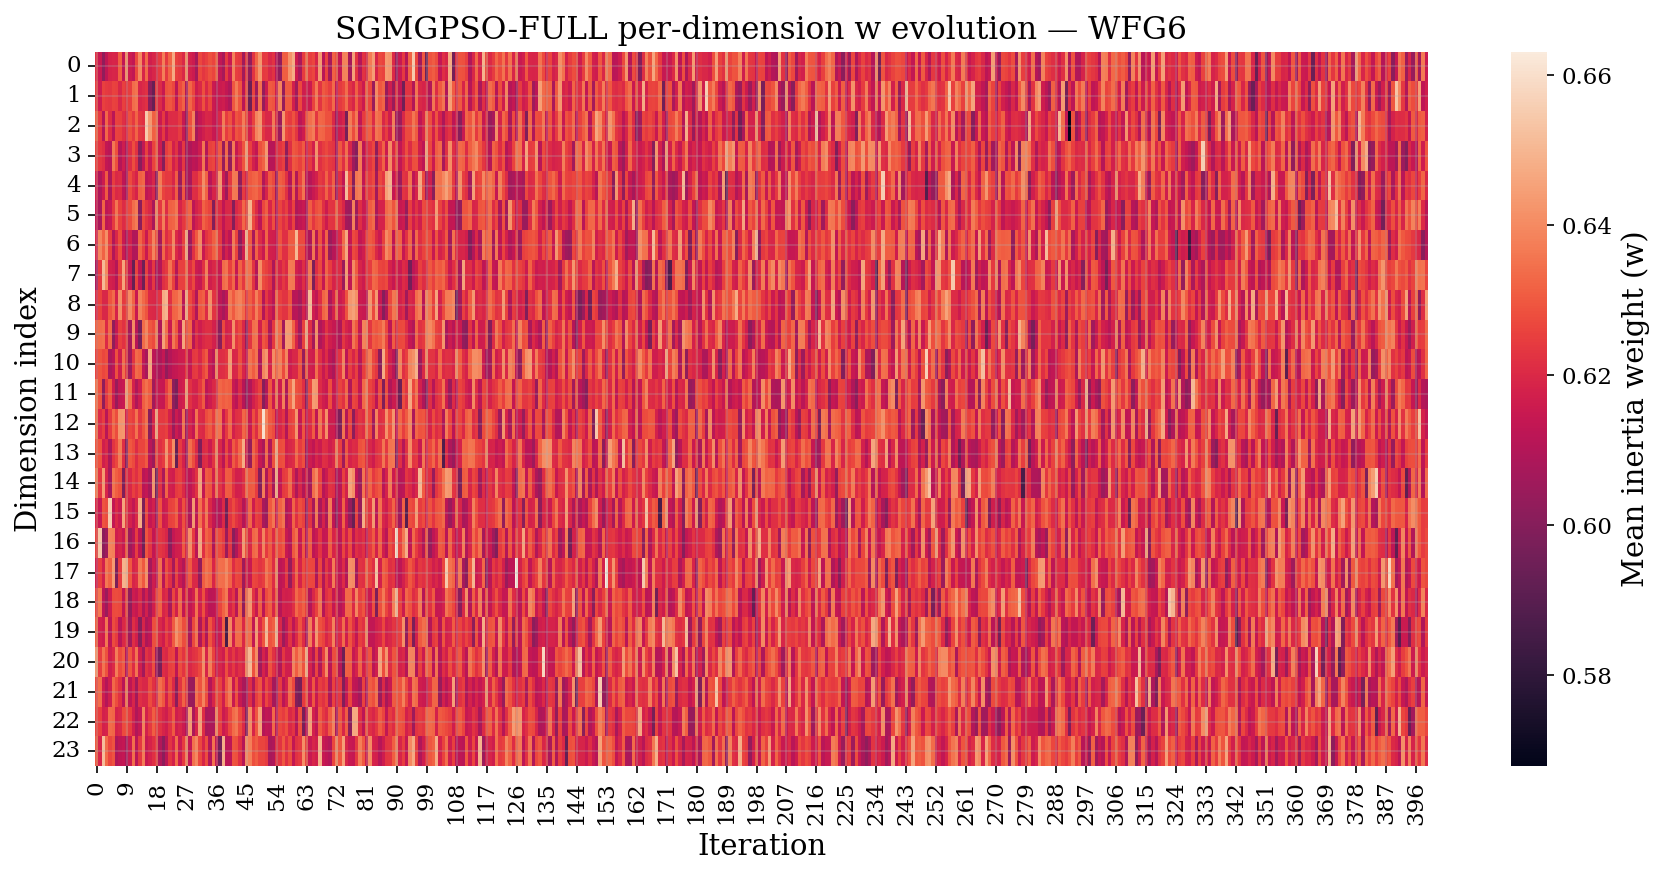

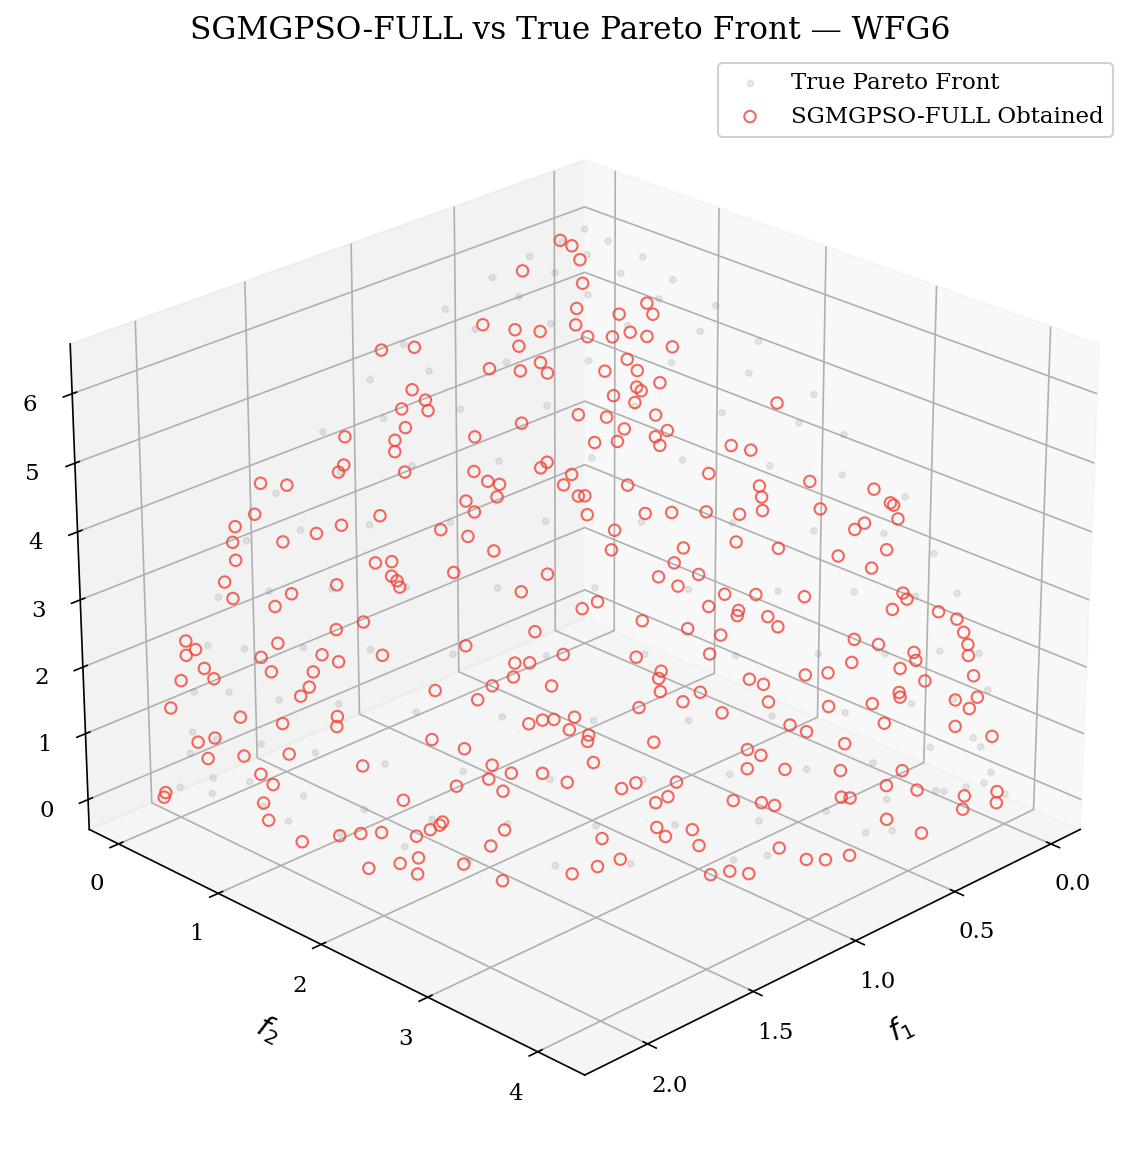


Processing: WFG7 (SGMGPSO-FULL)
  Trial 30/30 running...
  [Done] WFG7 — 30 trials completed.
  IGD: 0.382530 ± 0.011236
  HV:  63.204771 ± 0.494863


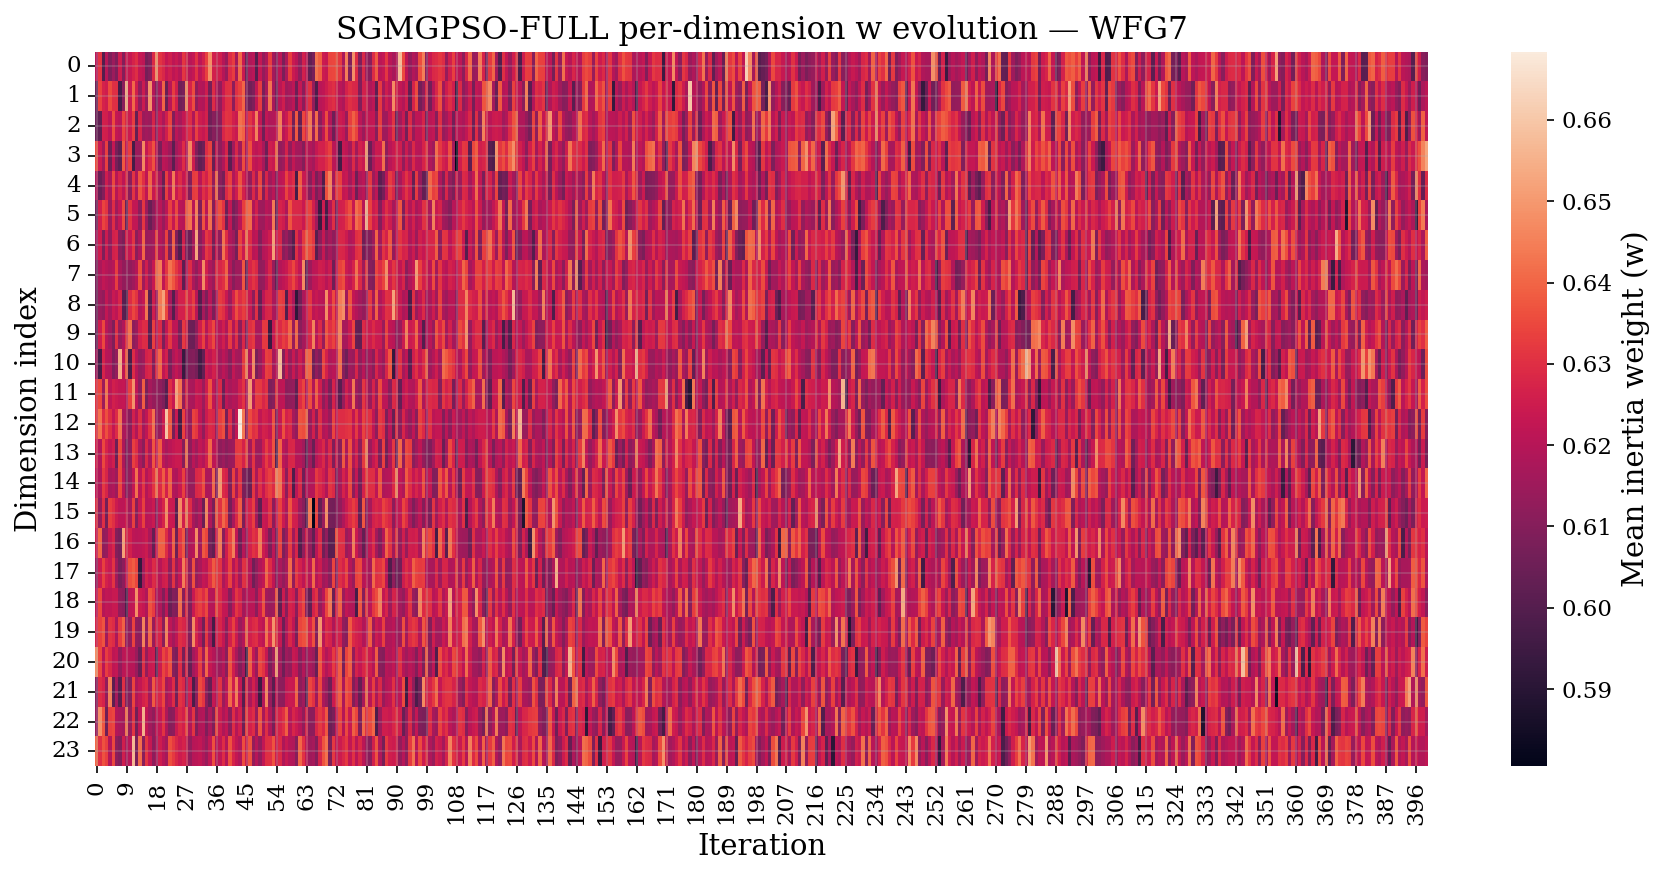

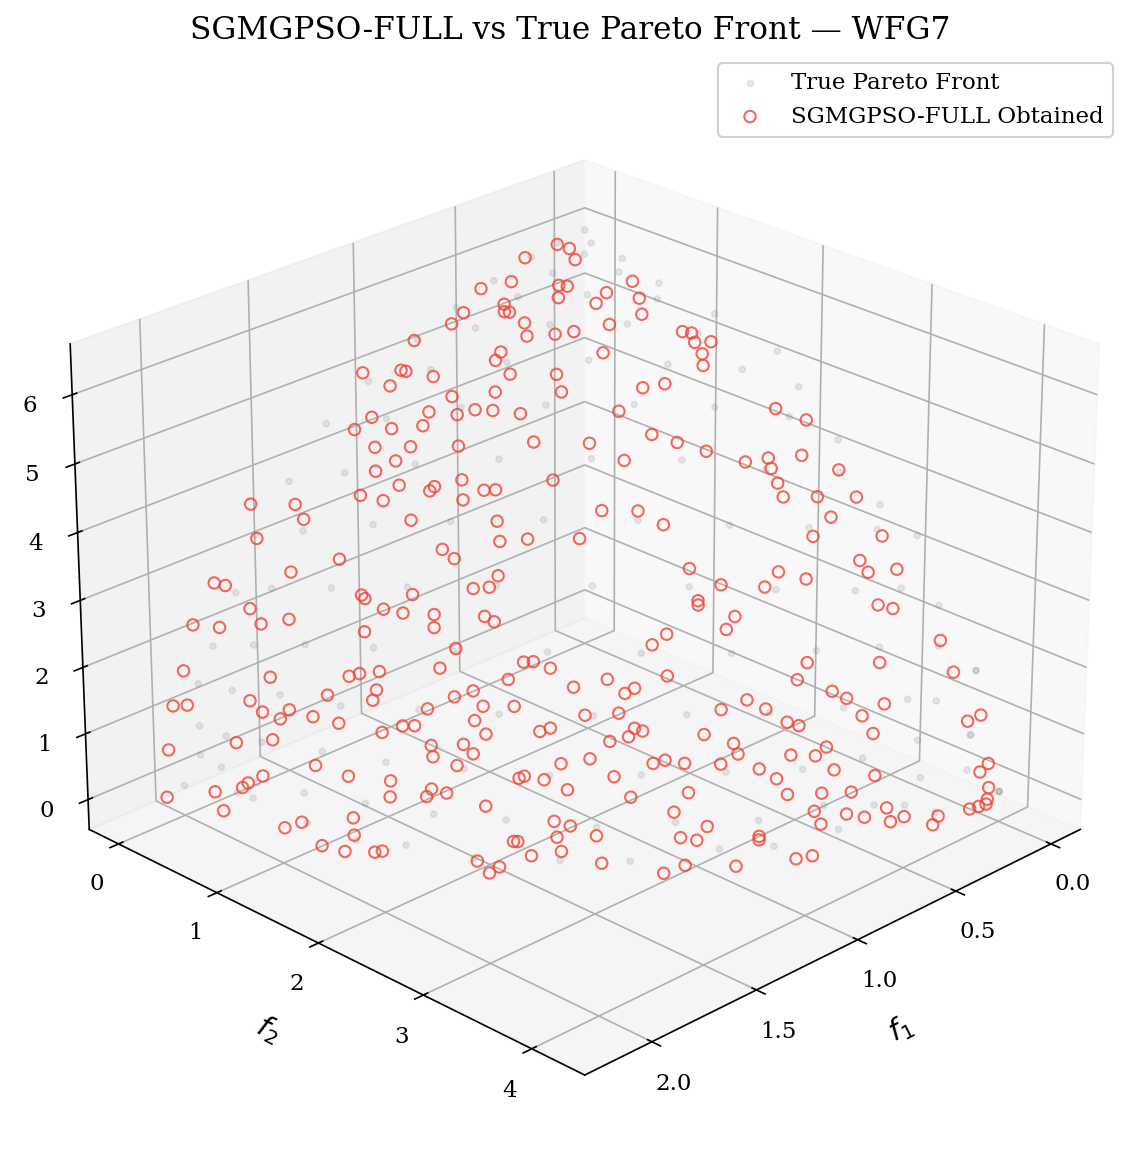


Processing: WFG8 (SGMGPSO-FULL)
  Trial 30/30 running...
  [Done] WFG8 — 30 trials completed.
  IGD: 0.442680 ± 0.013281
  HV:  59.351400 ± 0.730826


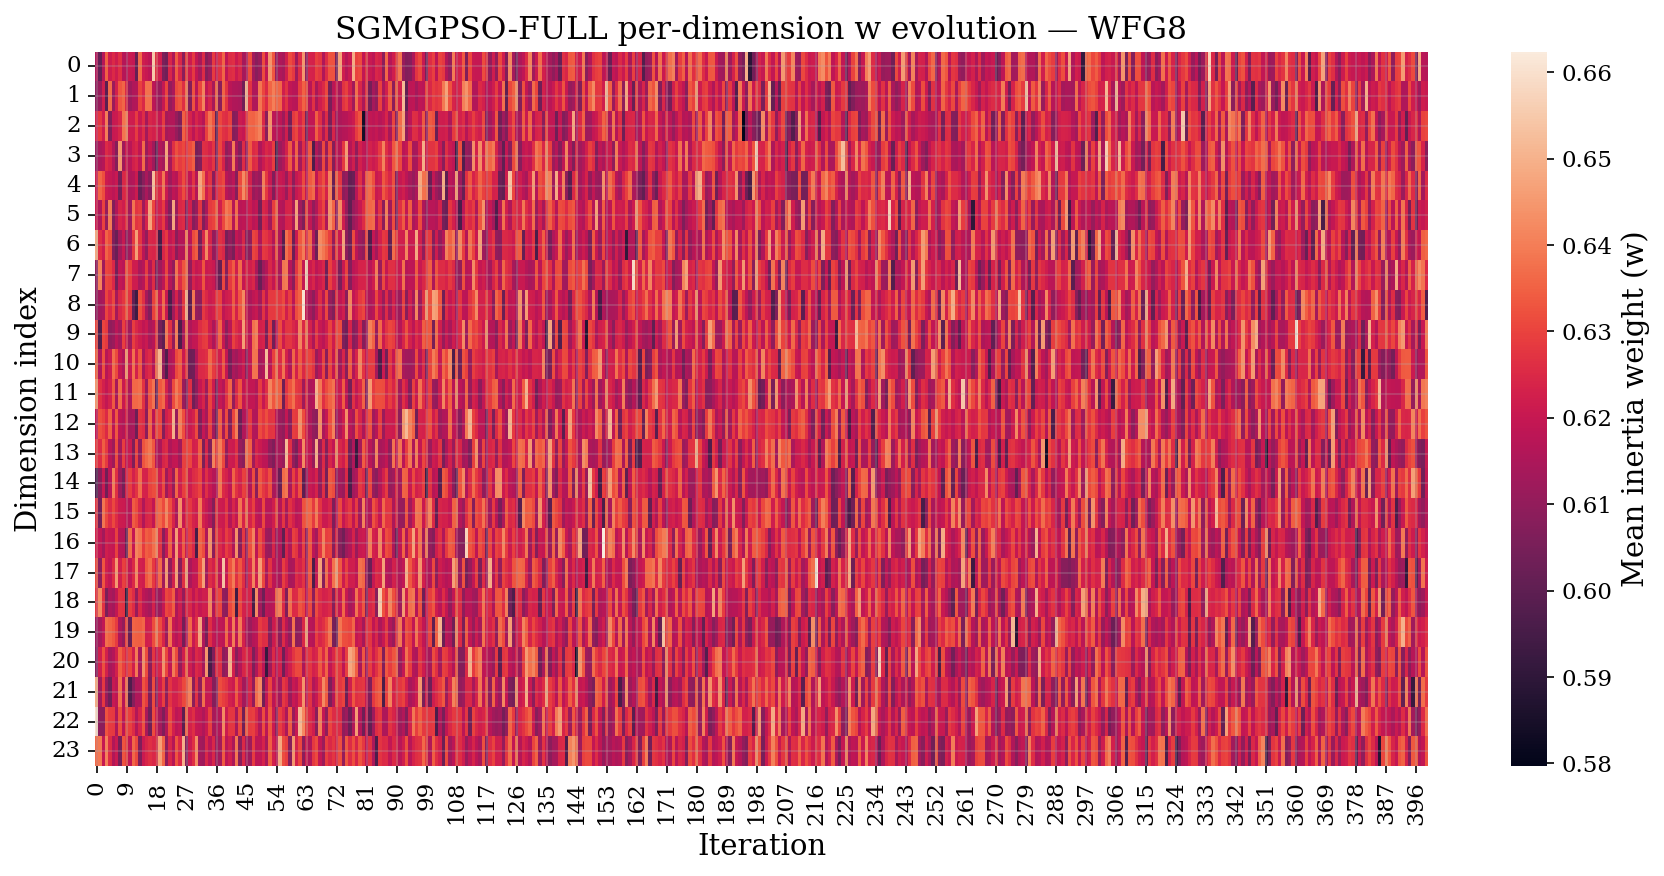

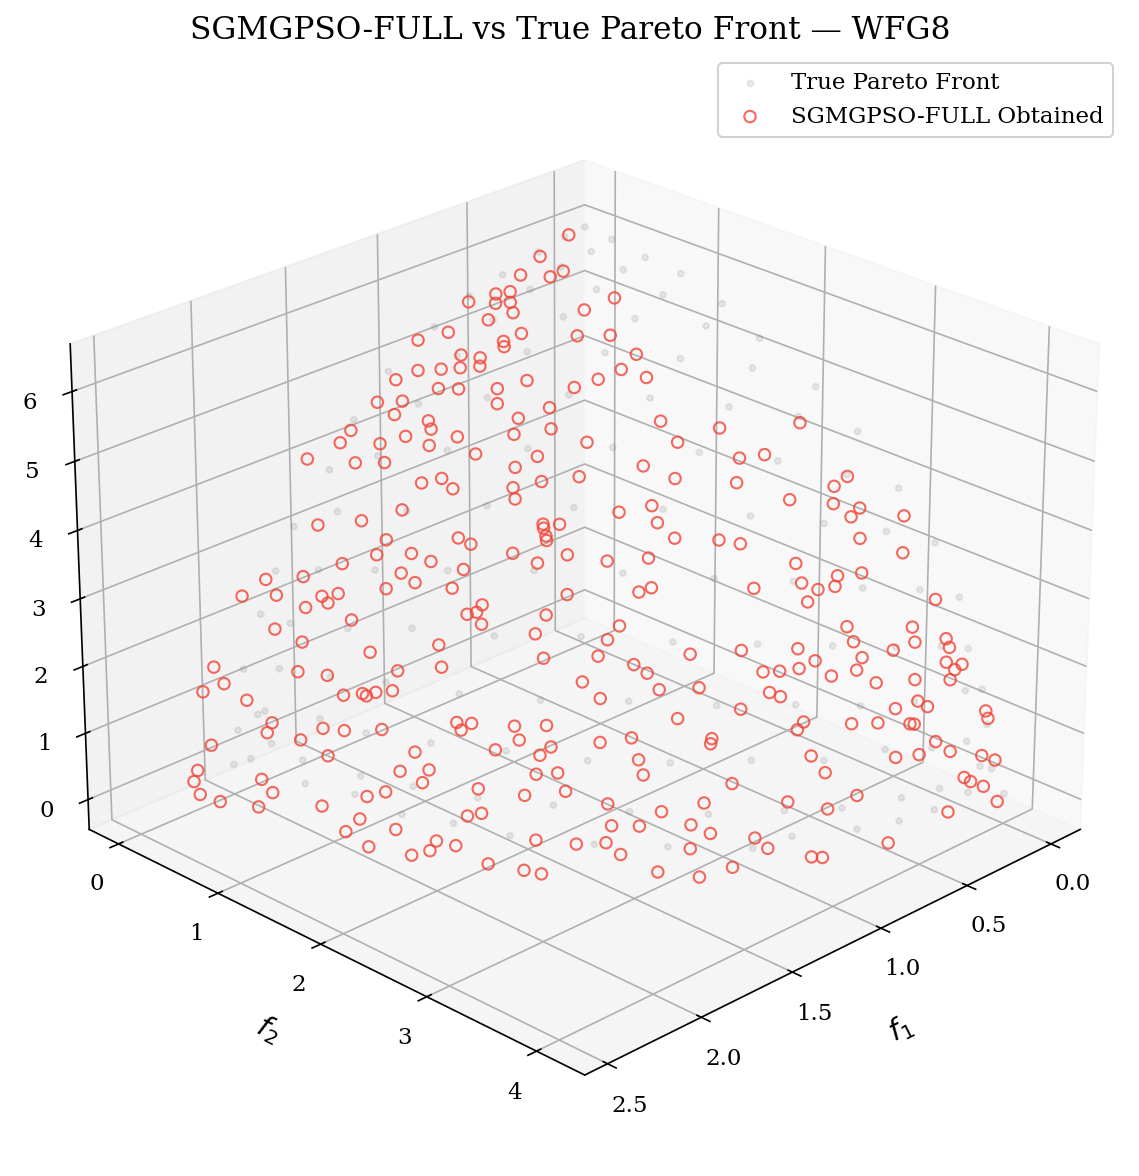


Processing: WFG9 (SGMGPSO-FULL)
  Trial 30/30 running...
  [Done] WFG9 — 30 trials completed.
  IGD: 0.259573 ± 0.006654
  HV:  67.158207 ± 0.300438


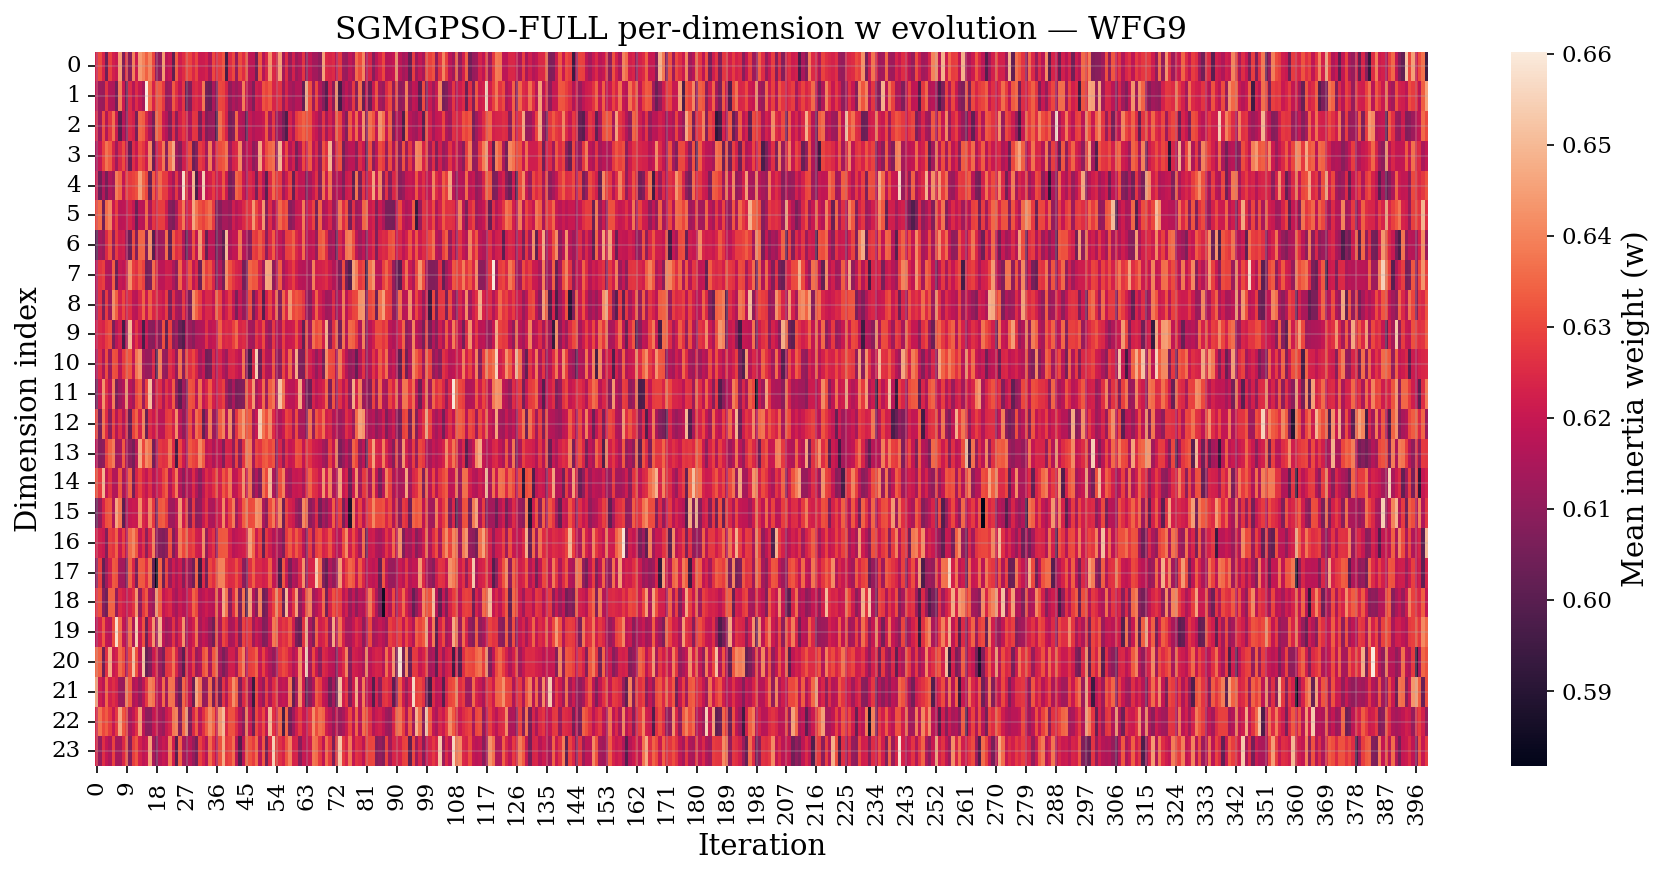

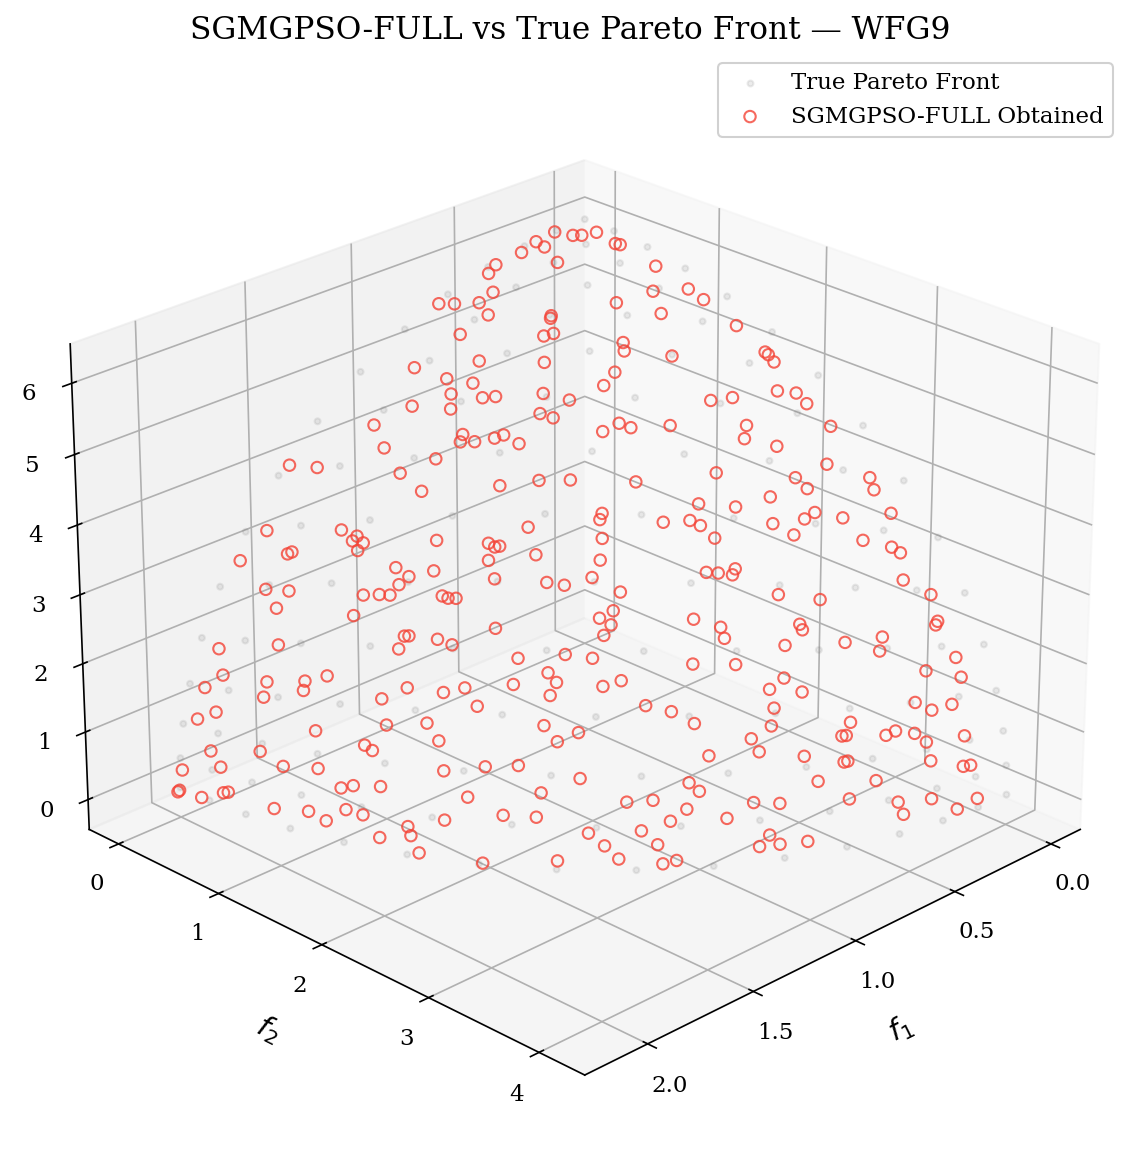


FINAL SUMMARY TABLE — SGMGPSO-FULL
Function  IGD_Mean  IGD_Std   HV_Mean   HV_Std
    ZDT1  0.003936 0.000307  5.902020 0.002709
    ZDT2  0.026514 0.016496  5.193729 0.203554
    ZDT3  0.010351 0.002024  7.389936 0.011597
    ZDT4 16.701162 3.475883  0.000000 0.000000
    ZDT6  0.001142 0.000086  5.153511 0.000020
    WFG1  1.428454 0.019600 45.035514 0.548683
    WFG2  0.322454 0.101614 90.582110 4.662461
    WFG3  0.248896 0.028054 66.420844 1.093959
    WFG4  0.230761 0.007138 69.789158 0.303843
    WFG5  0.472887 0.114580 56.068602 4.882350
    WFG6  0.317614 0.014837 66.122876 0.663496
    WFG7  0.382530 0.011236 63.204771 0.494863
    WFG8  0.442680 0.013281 59.351400 0.730826
    WFG9  0.259573 0.006654 67.158207 0.300438


In [1]:
!pip install pymoo numpy pandas matplotlib


import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pymoo.core.population import Population
from pymoo.problems import get_problem
from pymoo.indicators.igd import IGD
from pymoo.indicators.hv import HV
from pymoo.algorithms.moo.nsga2 import RankAndCrowdingSurvival

# MODEL 6: SGMGPSO-FULL (PP-PD + TVSR Combined) — IMPROVED
#
# Improvements over baseline SGMGPSO-FULL:
#   [1] Fully vectorized PP-PD stability sampling (no Python loops)
#   [2] Fully vectorized velocity update (pre-fetched guides)
#   [3] EMA-smoothed per-dimension convergence signal
#   [4] Adaptive polynomial mutation strength per dimension
#   [5] Crowding-distance-aware pbest update rule
#   [6] Adaptive archive tournament size

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3
})

ALGO_NAME   = "SGMGPSO-FULL"
N_PARTICLES = 150
ARCHIVE_SIZE = 300
N_RUNS       = 30

# ──────────────────────────────────────────────────────────────
# IMPROVEMENT [1]: Fully vectorized PP-PD stability sampling
# ──────────────────────────────────────────────────────────────
def sample_full_stability_matrix(n_particles, n_dims, w_bounds):
    """
    Samples unique (w, lambda, c1, c2, c3) for every (particle, dimension)
    pair from time-varying stability bounds.

    Fully vectorized — no Python-level row/col iteration.
    Runs up to 60 batch attempts; unfilled entries keep safe defaults.
    """
    # Safe defaults (guaranteed stable)
    W  = np.full((n_particles, n_dims), 0.4)
    L  = np.full((n_particles, n_dims), 0.5)
    C1 = np.full((n_particles, n_dims), 1.2)
    C2 = np.full((n_particles, n_dims), 1.2)
    C3 = np.full((n_particles, n_dims), 1.8)
    filled = np.zeros((n_particles, n_dims), dtype=bool)

    # Build per-dimension bound arrays — shape (n_dims,)
    w_min_arr = np.array([max(0.05, b[0]) for b in w_bounds])
    w_max_arr = np.array([min(0.95, b[1]) for b in w_bounds])
    w_max_arr = np.maximum(w_max_arr, w_min_arr + 0.05)  # enforce gap

    # Broadcast to (n_particles, n_dims) once
    w_lo = np.broadcast_to(w_min_arr, (n_particles, n_dims))
    w_hi = np.broadcast_to(w_max_arr, (n_particles, n_dims))

    for _ in range(60):
        if filled.all():
            break

        # Sample entire (n_particles × n_dims) matrix at once
        w  = np.random.uniform(w_lo, w_hi)
        lm = np.random.uniform(0.2, 0.8,  (n_particles, n_dims))
        c1 = np.random.uniform(0.5, 2.0,  (n_particles, n_dims))
        c2 = np.random.uniform(0.5, 2.0,  (n_particles, n_dims))
        c3 = np.random.uniform(0.5, 3.0,  (n_particles, n_dims))

        C     = c1 + lm * c2 + (1.0 - lm) * c3
        C_var = c1**2 + lm**2 * c2**2 + (1.0 - lm)**2 * c3**2
        num   = 4.0 * (1.0 - w**2)
        den   = (1.0 - w) + C_var * (1.0 + w) / (3.0 * C**2 + 1e-10)

        valid  = (C > 0) & (den > 0) & (C < num / (den + 1e-10))
        accept = (~filled) & valid          # only update unfilled valid entries

        W[accept]  = w[accept]
        L[accept]  = lm[accept]
        C1[accept] = c1[accept]
        C2[accept] = c2[accept]
        C3[accept] = c3[accept]
        filled    |= accept

    return W, L, C1, C2, C3


# ──────────────────────────────────────────────────────────────
# IMPROVEMENT [4]: Adaptive polynomial mutation per dimension
# ──────────────────────────────────────────────────────────────
def adaptive_polynomial_mutation(X, xl, xu, shift_d, eta_base=20):
    """
    Polynomial mutation where eta adapts per dimension based on convergence.
    Converged dimensions (shift_d → 1) get lower eta → stronger perturbation.
    Range: eta ∈ [5, 30].
    """
    n, d = X.shape
    prob = 1.0 / d
    mut_mask = np.random.random((n, d)) < prob

    # eta shape (d,) — broadcast over particles
    eta = eta_base + (1.0 - shift_d) * 10.0 - shift_d * 15.0
    eta = np.clip(eta, 5.0, 30.0)            # shape (d,)

    delta = xu - xl
    delta = np.where(delta < 1e-10, 1e-10, delta)

    u      = np.random.random((n, d))
    delta1 = np.clip((X - xl) / delta, 0, 1)
    delta2 = np.clip((xu - X) / delta, 0, 1)

    pow_val = 1.0 / (eta + 1.0)             # shape (d,), broadcasts fine

    mask_low = u <= 0.5

    xy           = 1.0 - delta1
    val          = 2.0 * u + (1.0 - 2.0 * u) * np.power(np.clip(xy, 0, None), eta + 1.0)
    deltaq_low   = np.power(np.clip(val, 0, None), pow_val) - 1.0

    xy           = 1.0 - delta2
    val          = 2.0 * (1.0 - u) + 2.0 * (u - 0.5) * np.power(np.clip(xy, 0, None), eta + 1.0)
    deltaq_high  = 1.0 - np.power(np.clip(val, 0, None), pow_val)

    deltaq    = np.where(mask_low, deltaq_low, deltaq_high)
    X_mutated = X + deltaq * delta * mut_mask
    return np.clip(X_mutated, xl, xu)


# ──────────────────────────────────────────────────────────────
# Archive utilities
# ──────────────────────────────────────────────────────────────
def update_archive(problem, archive, new_pop, max_size=ARCHIVE_SIZE):
    """Updates external archive using pymoo RankAndCrowding survival."""
    if archive is None or len(archive) == 0:
        combined = new_pop
    else:
        combined = Population.merge(archive, new_pop)
    survival = RankAndCrowdingSurvival()
    return survival.do(problem, combined, n_survive=min(len(combined), max_size))


def tournament_selection_archive(archive, size=5):
    """
    Tournament selection for archive guide using crowding distance.

    IMPROVEMENT [6]: size is passed from caller and scaled adaptively.
    """
    if archive is None or len(archive) == 0:
        return None
    indices    = np.random.choice(len(archive), min(size, len(archive)), replace=False)
    candidates = archive[indices]
    cds        = candidates.get("crowding")
    if cds is not None:
        cds_safe = np.nan_to_num(cds, nan=0.0, posinf=1e6)
        return candidates[np.argmax(cds_safe)].x
    return candidates[np.random.randint(len(candidates))].x


# ──────────────────────────────────────────────────────────────
# Main SGMGPSO-FULL Logic (all improvements integrated)
# ──────────────────────────────────────────────────────────────
def run_sgmgpso_full(problem_obj, n_particles=N_PARTICLES, n_gen=300, seed=0):
    np.random.seed(seed)
    xl, xu   = problem_obj.bounds()
    n_dims   = problem_obj.n_var
    vmax     = 0.2 * (xu - xl)

    # ── Initialize swarm ──────────────────────────────────────
    X = np.random.uniform(xl, xu, (n_particles, n_dims))
    V = np.random.uniform(-0.1 * (xu - xl), 0.1 * (xu - xl), (n_particles, n_dims))
    F = problem_obj.evaluate(X)

    pop             = Population.new("X", X, "F", F)
    pbest_X         = np.copy(X)
    pbest_F         = np.copy(F)
    archive         = update_archive(problem_obj, Population(), pop)
    w_history       = np.zeros((n_gen, n_dims))

    # IMPROVEMENT [3]: initialise EMA of convergence signal
    conv_0   = np.std(V, axis=0) / (np.std(X, axis=0) + 1e-10)  # shape (n_dims,)
    conv_ema = conv_0.copy()
    ema_alpha = 0.15   # smoothing factor (0.1–0.3 recommended)

    # Ring topology neighbour indices (static — topology fixed)
    ring_radius = 3
    nb_indices  = np.array([
        np.arange(i - ring_radius, i + ring_radius + 1) % n_particles
        for i in range(n_particles)
    ])  # shape (n_particles, 2*ring_radius+1)

    # ── Generation loop ───────────────────────────────────────
    for gen in range(n_gen):

        # ── [3] EMA-smoothed per-dimension convergence ────────
        conv_t   = np.std(V, axis=0) / (np.std(X, axis=0) + 1e-10)
        conv_ema = ema_alpha * conv_t + (1.0 - ema_alpha) * conv_ema
        shift_d  = np.clip(1.0 - conv_ema / (conv_0 + 1e-10), 0.0, 1.0)  # (n_dims,)

        w_min_d  = 0.4 - 0.3 * shift_d   # shape (n_dims,)
        w_max_d  = 0.9 - 0.5 * shift_d
        w_bounds = list(zip(w_min_d, w_max_d))

        # ── [1] Vectorized PP-PD stability sampling ───────────
        W, L, C1, C2, C3 = sample_full_stability_matrix(n_particles, n_dims, w_bounds)
        w_history[gen, :] = np.mean(W, axis=0)

        # ── [2] Pre-fetch all guides (vectorized) ─────────────
        # Neighborhood bests — shape (n_particles, n_dims)
        nb_pbest_F  = pbest_F[nb_indices]       # (n, 7, n_obj)
        nb_sum_F    = nb_pbest_F.sum(axis=2)    # (n, 7)
        lbest_local = nb_indices[
            np.arange(n_particles),
            nb_sum_F.argmin(axis=1)
        ]                                        # (n,) indices into pbest_X
        lbests = pbest_X[lbest_local]            # (n_particles, n_dims)

        # Archive guides — shape (n_particles, n_dims)
        # [6] Adaptive tournament size: 5% of archive, minimum 5
        t_size = max(5, int(0.05 * len(archive)))
        a_hats = np.array([
            tournament_selection_archive(archive, size=t_size)
            for _ in range(n_particles)
        ])
        # Fallback: replace None entries with lbest
        none_mask = np.array([a is None for a in a_hats])
        if none_mask.any():
            a_hats_arr = np.where(
                none_mask[:, None],
                lbests,
                np.stack([a if a is not None else lbests[i]
                           for i, a in enumerate(a_hats)])
            )
        else:
            a_hats_arr = np.stack(a_hats)       # (n_particles, n_dims)

        # ── [2] Fully vectorized velocity & position update ───
        r1 = np.random.random((n_particles, n_dims))
        r2 = np.random.random((n_particles, n_dims))
        r3 = np.random.random((n_particles, n_dims))

        V = (W * V
             + C1 * r1 * (pbest_X - X)
             + L  * C2 * r2 * (lbests - X)
             + (1.0 - L) * C3 * r3 * (a_hats_arr - X))

        V = np.clip(V, -vmax, vmax)
        X = np.clip(X + V, xl, xu)

        # ── [4] Adaptive polynomial mutation ─────────────────
        X = adaptive_polynomial_mutation(X, xl, xu, shift_d, eta_base=20)

        # ── Evaluate ──────────────────────────────────────────
        F   = problem_obj.evaluate(X)
        pop = Population.new("X", X, "F", F)

        # ── [5] Crowding-distance-aware pbest update ──────────
        for i in range(n_particles):
            dominates_pbest = (np.all(F[i] <= pbest_F[i]) and
                               np.any(F[i] <  pbest_F[i]))
            dominated_by_pbest = (np.all(pbest_F[i] <= F[i]) and
                                  np.any(pbest_F[i] <  F[i]))

            if dominates_pbest:
                # New position is better — always update
                pbest_X[i] = np.copy(X[i])
                pbest_F[i] = np.copy(F[i])
            elif not dominated_by_pbest:
                # Non-dominated pair: prefer the more spread solution
                spread_new   = np.std(F[i])
                spread_pbest = np.std(pbest_F[i])
                if spread_new >= spread_pbest:
                    # New position is more diverse → update
                    pbest_X[i] = np.copy(X[i])
                    pbest_F[i] = np.copy(F[i])
                elif np.random.random() < 0.3:
                    # Small fallback probability for diversity
                    pbest_X[i] = np.copy(X[i])
                    pbest_F[i] = np.copy(F[i])

        # ── Archive update ────────────────────────────────────
        archive = update_archive(problem_obj, archive, pop)

    return archive, w_history


# ──────────────────────────────────────────────────────────────
# Publication-quality plotting
# ──────────────────────────────────────────────────────────────
def plot_pareto_comparison_2d(pf, obtained_F, algo_name, func_name,
                               output_path, color='#F44336'):
    fig, ax = plt.subplots(figsize=(8, 6))
    if pf is not None:
        sorted_pf = pf[pf[:, 0].argsort()]
        ax.plot(sorted_pf[:, 0], sorted_pf[:, 1],
                color='black', lw=2.0, label='True Pareto Front',
                alpha=0.85, zorder=5)
    ax.scatter(obtained_F[:, 0], obtained_F[:, 1],
               facecolor='none', edgecolor=color, s=40, linewidths=1.2,
               label=f'{algo_name} Obtained', alpha=0.85, zorder=10)
    ax.set_xlabel(r'$f_1$')
    ax.set_ylabel(r'$f_2$')
    ax.set_title(f'{algo_name} vs True Pareto Front — {func_name}')
    ax.legend(loc='best', framealpha=0.9)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_pareto_comparison_3d(pf, obtained_F, algo_name, func_name,
                               output_path, color='#F44336'):
    fig = plt.figure(figsize=(10, 8))
    ax  = fig.add_subplot(111, projection='3d')
    if pf is not None:
        ax.scatter(pf[:, 0], pf[:, 1], pf[:, 2],
                   c='gray', s=8, label='True Pareto Front',
                   alpha=0.15, zorder=1)
    ax.scatter(obtained_F[:, 0], obtained_F[:, 1], obtained_F[:, 2],
               facecolor='none', edgecolor=color, s=30, linewidths=1.0,
               label=f'{algo_name} Obtained', alpha=0.8, zorder=10)
    ax.set_xlabel(r'$f_1$', labelpad=10)
    ax.set_ylabel(r'$f_2$', labelpad=10)
    ax.set_zlabel(r'$f_3$', labelpad=10)
    ax.set_title(f'{algo_name} vs True Pareto Front — {func_name}')
    ax.legend(loc='best', framealpha=0.9)
    ax.view_init(elev=25, azim=45)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_w_heatmap(w_history, func_name, output_path):
    """Per-dimension inertia weight heatmap over generations."""
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(w_history.T, cmap='rocket', ax=ax,
                cbar_kws={'label': 'Mean inertia weight (w)'})
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Dimension index')
    ax.set_title(f'SGMGPSO-FULL per-dimension w evolution — {func_name}')
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


# ──────────────────────────────────────────────────────────────
# Experiment runner
# ──────────────────────────────────────────────────────────────
def main():
    benchmarks = [
        "zdt1", "zdt2", "zdt3", "zdt4", "zdt6",
        "wfg1", "wfg2", "wfg3", "wfg4",
        "wfg5", "wfg6", "wfg7", "wfg8", "wfg9"
    ]

    all_results = []

    for b_name in benchmarks:
        print(f"\n{'='*60}")
        print(f"Processing: {b_name.upper()} ({ALGO_NAME})")
        print(f"{'='*60}")

        output_dir = f"./results/SGMGPSO_FULL/{b_name}/"
        os.makedirs(output_dir, exist_ok=True)

        is_wfg  = b_name.lower().startswith("wfg")
        problem = (get_problem(b_name, n_var=24, n_obj=3, k=4)
                   if is_wfg else get_problem(b_name))

        # Generation budgets (increased for harder problems)
        n_gen = 400 if is_wfg else 300
        if b_name.lower() == 'zdt4':
            n_gen = 600   # multimodal — extra budget benefits FULL most

        pf        = problem.pareto_front()
        ref_point = (np.array([3.0, 5.0, 7.0])
                     if is_wfg else np.ones(problem.n_obj) * 2.5)

        run_results = []
        best_igd    = np.inf
        best_F      = None
        best_w_hist = None

        for run in range(N_RUNS):
            print(f"  Trial {run + 1}/{N_RUNS} running...", end="\r")
            res_archive, w_hist = run_sgmgpso_full(
                problem, n_gen=n_gen, seed=run
            )
            F_run = res_archive.get("F")

            igd = IGD(pf).do(F_run) if pf is not None else np.nan
            hv  = HV(ref_point=ref_point).do(F_run) if pf is not None else np.nan

            run_results.append({"run": run + 1, "IGD": igd, "HV": hv})

            if igd < best_igd:
                best_igd    = igd
                best_F      = F_run.copy()
                best_w_hist = w_hist.copy()

        print(f"\n  [Done] {b_name.upper()} — {N_RUNS} trials completed.")

        df = pd.DataFrame(run_results)
        df.to_csv(f"{output_dir}metrics.csv", index=False)

        igd_mean, igd_std = df['IGD'].mean(), df['IGD'].std()
        hv_mean,  hv_std  = df['HV'].mean(),  df['HV'].std()

        print(f"  IGD: {igd_mean:.6f} ± {igd_std:.6f}")
        print(f"  HV:  {hv_mean:.6f} ± {hv_std:.6f}")

        all_results.append({
            'Function': b_name.upper(),
            'IGD_Mean': igd_mean, 'IGD_Std': igd_std,
            'HV_Mean':  hv_mean,  'HV_Std':  hv_std
        })

        # Plots
        if best_w_hist is not None:
            plot_w_heatmap(
                best_w_hist, b_name.upper(),
                f"{output_dir}w_heatmap.png"
            )

        if problem.n_obj == 2:
            plot_pareto_comparison_2d(
                pf, best_F, ALGO_NAME, b_name.upper(),
                f"{output_dir}pareto_front_comparison.png"
            )
        else:
            plot_pareto_comparison_3d(
                pf, best_F, ALGO_NAME, b_name.upper(),
                f"{output_dir}pareto_front_comparison.png"
            )

    # Final summary
    print(f"\n{'='*80}")
    print(f"FINAL SUMMARY TABLE — {ALGO_NAME}")
    print(f"{'='*80}")
    summary_df = pd.DataFrame(all_results)
    os.makedirs("./results/SGMGPSO_FULL/", exist_ok=True)
    summary_df.to_csv("./results/SGMGPSO_FULL/summary.csv", index=False)
    print(summary_df.to_string(index=False))


if __name__ == "__main__":
    main()
